In [2]:
print("start")

start


All sanity checks passed.


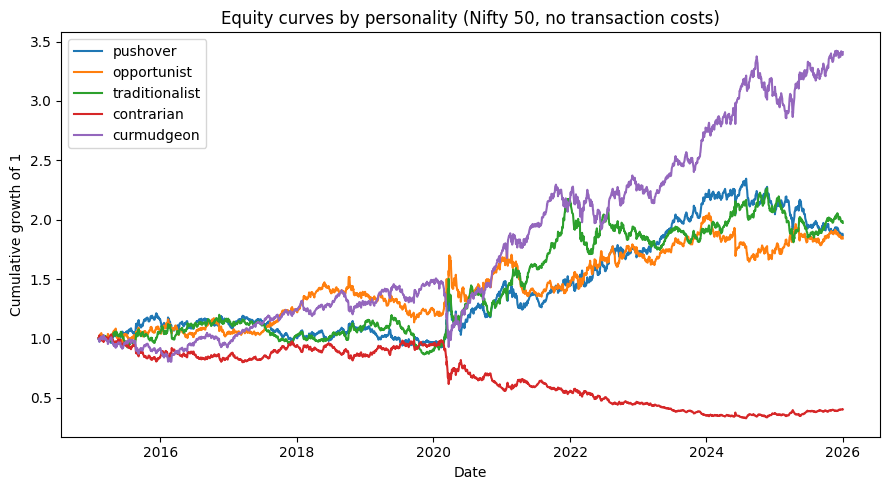

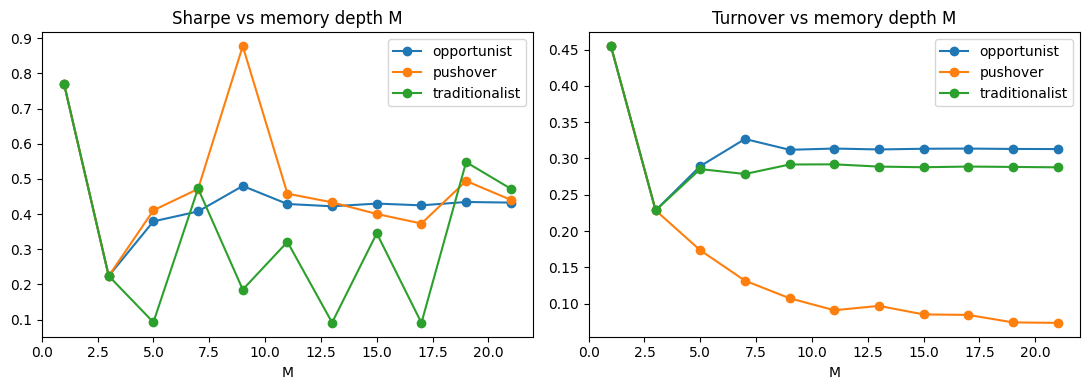

,personality,ann_return,ann_vol,sharpe,max_drawdown,hit_rate,turnover,avg_holding_days,M
0,pushover,0.124702,0.161970,0.769905,-0.421212,0.544987,0.454646,2.199515,1
1,opportunist,0.124702,0.161970,0.769905,-0.421212,0.544987,0.454646,2.199515,1
2,traditionalist,0.124702,0.161970,0.769905,-0.421212,0.544987,0.454646,2.199515,1
3,pushover,0.036290,0.161945,0.224091,-0.396538,0.530687,0.228592,4.374598,3
4,opportunist,0.036290,0.161945,0.224091,-0.396538,0.530687,0.228592,4.374598,3
5,traditionalist,0.036290,0.161945,0.224091,-0.396538,0.530687,0.228592,4.374598,3
6,pushover,0.066493,0.161879,0.410755,-0.390430,0.527400,0.173593,5.760593,5
7,opportunist,0.061408,0.161887,0.379328,-0.258509,0.532917,0.289445,3.454892,5
8,traditionalist,0.014989,0.161930,0.092566,-0.424870,0.518205,0.285399,3.503866,5
9,pushover,0.076343,0.161913,0.471506,-0.360539,0.531100,0.131763,7.589385,7


In [3]:
# %% [markdown]
# ## CONFIG
# Single source of truth — change parameters here only.

# %%
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---- Data ----
DATA_PATH = "/Users/anujkothari/BTP/Nifty1500_Final_Standardized/nifty50_tri.csv"   # <-- set this to your local CSV
DATE_COL = "timestamp"
CLOSE_COL = "close"

# ---- Memory / kernel parameters ----
M = 21                      # memory depth (number of past return-signs in the queue)
B_OPPORTUNIST = 1.5         # w_i = b^t, b > 1 -> recency-weighted (fast momentum)
B_TRADITIONALIST = 0.7      # w_i = b^t, b < 1 -> distance-weighted (slow momentum)
CURMUDGEON_BIAS = 1         # fixed position: +1 (always long) or -1 (always short)

# ---- Signal / lookahead safety ----
LAG_DAYS = 1                # signal decided on info through t-1, applied to day t's return
ENFORCE_LOOKAHEAD_CHECK = True

# ---- M-sweep ----
M_SWEEP = [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21]

PERSONALITIES = ["pushover", "opportunist", "traditionalist", "contrarian", "curmudgeon"]
ANNUALIZATION = 252

# %% [markdown]
# ## Data: load OHLCV, compute daily return sign (the "memory bit" q_t), lag by LAG_DAYS

# %%
def load_returns(path=DATA_PATH, date_col=DATE_COL, close_col=CLOSE_COL):
    df = pd.read_csv(path)
    if date_col not in df.columns or close_col not in df.columns:
        raise ValueError(
            f"Expected columns '{date_col}' and '{close_col}' in {path}, got {list(df.columns)}"
        )
    df[date_col] = pd.to_datetime(df[date_col])
    df = df.sort_values(date_col).reset_index(drop=True)

    df["ret"] = df[close_col].pct_change()
    df["q"] = np.sign(df["ret"])
    df.loc[df["q"] == 0, "q"] = 1.0  # tie-break: flat day treated as "+"

    df = df.dropna(subset=["ret"]).reset_index(drop=True)
    return df[[date_col, close_col, "ret", "q"]].rename(columns={date_col: "date", close_col: "close"})


def build_lagged_q(df, lag_days=LAG_DAYS):
    """
    q_lagged[t] is the memory bit KNOWN before day t's signal is computed.
    Signals must only ever reference q_lagged, never df['q'] directly.
    """
    df = df.copy()
    df["q_lagged"] = df["q"].shift(lag_days)
    return df


def assert_no_lookahead(signal_series, q_lagged_series):
    if not ENFORCE_LOOKAHEAD_CHECK:
        return
    bad = signal_series.notna() & q_lagged_series.isna()
    if bad.any():
        raise RuntimeError(
            f"Lookahead violation: signal defined at {bad.sum()} rows "
            f"where lagged memory bit is not yet available."
        )


df = load_returns()
df = build_lagged_q(df)
df.tail()

# %% [markdown]
# ## Signal kernels: the 5 personalities from Li et al. (2026)
#
# Sigma_d = sum_i w_i * q_i  ->  s = sign(Sigma_d)
#
# Window convention: index 0 = oldest observation, index M-1 = most recent.
#
# - **pushover**: w_i = 1 (flat momentum vote)
# - **opportunist**: w_i = b^i, b>1 (recency-weighted, fast)
# - **traditionalist**: w_i = b^i, b<1 (distance-weighted, slow)
# - **contrarian**: s = -pushover(s) (mean reversion)
# - **curmudgeon**: s = constant, ignores q entirely

# %%
def _rolling_weighted_sign(q_lagged, M, weights):
    vals = q_lagged.values.astype(float)
    n = len(vals)
    out = np.full(n, np.nan)

    if n >= M:
        windows = np.lib.stride_tricks.sliding_window_view(vals, M)  # (n-M+1, M)
        valid = ~np.isnan(windows).any(axis=1)
        sigma = windows @ weights
        sigma_full = np.full(windows.shape[0], np.nan)
        sigma_full[valid] = sigma[valid]
        out[M - 1:] = sigma_full

    sign = np.sign(out)
    sign[sign == 0] = 1.0
    return pd.Series(sign, index=q_lagged.index, name="signal")


def pushover(q_lagged, M=M):
    return _rolling_weighted_sign(q_lagged, M, np.ones(M))


def opportunist(q_lagged, M=M, b=B_OPPORTUNIST):
    if b <= 1:
        raise ValueError("opportunist requires b > 1")
    weights = b ** np.arange(M)  # most recent (index M-1) gets largest weight
    return _rolling_weighted_sign(q_lagged, M, weights)


def traditionalist(q_lagged, M=M, b=B_TRADITIONALIST):
    if not (0 < b < 1):
        raise ValueError("traditionalist requires 0 < b < 1")
    weights = b ** np.arange(M)  # oldest (index 0) gets largest weight
    return _rolling_weighted_sign(q_lagged, M, weights)


def contrarian(q_lagged, M=M):
    return -1.0 * pushover(q_lagged, M=M)


def curmudgeon(q_lagged, bias=CURMUDGEON_BIAS):
    return pd.Series(float(bias), index=q_lagged.index, name="signal")


KERNELS = {
    "pushover": pushover,
    "opportunist": opportunist,
    "traditionalist": traditionalist,
    "contrarian": contrarian,
    "curmudgeon": curmudgeon,
}


def build_all_signals(q_lagged, M=M):
    out = {}
    for name in PERSONALITIES:
        out[name] = curmudgeon(q_lagged) if name == "curmudgeon" else KERNELS[name](q_lagged, M)
    return pd.DataFrame(out)


signals = build_all_signals(df["q_lagged"])
signals.tail()

# %% [markdown]
# ## Sanity checks — run once after any edit to the kernels above

# %%
q = df["q_lagged"]

assert (pushover(q, M=1).dropna() == q.dropna()).all(), "pushover(M=1) != raw lagged sign"
assert ((contrarian(q) + pushover(q)).dropna() == 0).all(), "contrarian != -pushover"
assert curmudgeon(q).nunique() == 1, "curmudgeon signal is not constant"

for c in signals.columns:
    if c == "curmudgeon":
        continue  # curmudgeon ignores q by design; nothing to check
    assert_no_lookahead(signals[c], q)

print("All sanity checks passed.")

# %% [markdown]
# ## Backtest (no transaction costs)
# signal[t] is built purely from q_lagged (info through t-1), so
# signal[t] * ret[t] is a valid, lookahead-free strategy return for day t.

# %%
def run_backtest(M=M):
    signals = build_all_signals(df["q_lagged"], M=M)
    for c in signals.columns:
        if c == "curmudgeon":
            continue
        assert_no_lookahead(signals[c], df["q_lagged"])

    result = pd.DataFrame({"date": df["date"], "ret": df["ret"]})
    for name in signals.columns:
        result[f"pos_{name}"] = signals[name]
        result[f"strat_ret_{name}"] = signals[name] * df["ret"]

    return result.dropna().reset_index(drop=True)


bt = run_backtest()
bt.tail()

# %% [markdown]
# ## Performance metrics per personality

# %%
def _max_drawdown(equity):
    peak = equity.cummax()
    return ((equity - peak) / peak).min()


def _turnover(position):
    return (position.diff().abs() > 0).sum() / len(position)


def _avg_holding_period(position):
    flips = (position.diff().abs() > 0).sum()
    return len(position) / flips if flips > 0 else np.inf


def summarize(bt, name):
    strat_ret = bt[f"strat_ret_{name}"]
    position = bt[f"pos_{name}"]

    equity = (1 + strat_ret).cumprod()
    ann_return = strat_ret.mean() * ANNUALIZATION
    ann_vol = strat_ret.std() * np.sqrt(ANNUALIZATION)
    sharpe = ann_return / ann_vol if ann_vol > 0 else np.nan

    row = {
        "personality": name,
        "ann_return": ann_return,
        "ann_vol": ann_vol,
        "sharpe": sharpe,
        "max_drawdown": _max_drawdown(equity),
        "hit_rate": (strat_ret > 0).mean(),
        "turnover": _turnover(position),
        "avg_holding_days": _avg_holding_period(position),
    }
    return row, equity


rows, equities = [], {}
for name in PERSONALITIES:
    row, eq = summarize(bt, name)
    rows.append(row)
    equities[name] = eq

summary_table = pd.DataFrame(rows).set_index("personality")
summary_table.round(4)

# %% [markdown]
# ## Equity curves

# %%
plt.figure(figsize=(9, 5))
for name, eq in equities.items():
    plt.plot(bt["date"].values, eq.values, label=name)
plt.title("Equity curves by personality (Nifty 50, no transaction costs)")
plt.xlabel("Date")
plt.ylabel("Cumulative growth of 1")
plt.legend()
plt.tight_layout()
plt.show()

# %% [markdown]
# ## M-sweep: Sharpe & turnover vs memory depth
# Empirical analog of the paper's critical memory depth M_c — here applied
# to signal quality rather than population polarization.

# %%
def m_sweep(personalities=("pushover", "opportunist", "traditionalist"), M_list=M_SWEEP):
    records = []
    for m in M_list:
        bt_m = run_backtest(M=m)
        for name in personalities:
            row, _ = summarize(bt_m, name)
            row["M"] = m
            records.append(row)
    return pd.DataFrame(records)


sweep_df = m_sweep()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for name, g in sweep_df.groupby("personality"):
    axes[0].plot(g["M"], g["sharpe"], marker="o", label=name)
    axes[1].plot(g["M"], g["turnover"], marker="o", label=name)
axes[0].set_title("Sharpe vs memory depth M")
axes[0].set_xlabel("M")
axes[0].legend()
axes[1].set_title("Turnover vs memory depth M")
axes[1].set_xlabel("M")
axes[1].legend()
plt.tight_layout()
plt.show()

sweep_df

               ann_return  ann_vol  sharpe  max_drawdown  hit_rate  turnover  \
name                                                                           
kernel_blend       0.0697   0.1619  0.4303       -0.2521    0.5346    0.3137   
ensemble_vote      0.1122   0.1618  0.6935       -0.3625    0.5442    0.1487   
regime_switch      0.0618   0.1619  0.3814       -0.2829    0.5268    0.2383   

               avg_holding_days  
name                             
kernel_blend             3.1875  
ensemble_vote            6.7239  
regime_switch            4.1972  


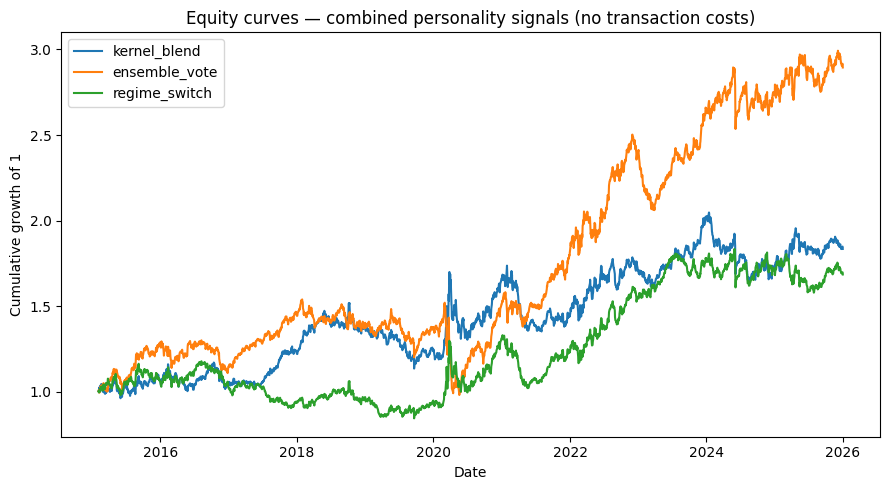

In [4]:
# %% [markdown]
# ## Personality Combination Framework (standalone)
#
# Self-contained script: loads data, builds the lagged memory bit q, and
# provides three ways to combine the 5 personality kernels
# (pushover / opportunist / traditionalist / contrarian / curmudgeon):
#
#   1. KERNEL BLENDING   — combine memory *weight vectors* before sign().
#                           Valid because Sigma_d = w . q is linear in w.
#   2. ENSEMBLE VOTING   — run each personality's signed signal separately,
#                           combine with a weighted vote. Closer analog to
#                           the paper: a population of differently-
#                           personalitied agents whose collective sign
#                           is what matters.
#   3. REGIME SWITCHING  — pick the active personality (or blend) based on
#                           a market-state variable (e.g. realized-vol
#                           regime), rather than fixing one for the whole run.
#
# Run this file top to bottom on its own — no dependency on any other
# notebook/script having already executed.

# %% [markdown]
# ## CONFIG — single source of truth

# %%
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---- Data ----
DATA_PATH = "/Users/anujkothari/BTP/Nifty1500_Final_Standardized/nifty50_tri.csv"   # <-- set this to your local CSV
DATE_COL = "timestamp"
CLOSE_COL = "close"

# ---- Memory / kernel parameters ----
M = 21                      # memory depth
B_OPPORTUNIST = 1.5         # w_i = b^t, b > 1 -> recency-weighted (fast momentum)
B_TRADITIONALIST = 0.7      # w_i = b^t, b < 1 -> distance-weighted (slow momentum)
CURMUDGEON_BIAS = 1         # fixed position: +1 (always long) or -1 (always short)

# ---- Signal / lookahead safety ----
LAG_DAYS = 1                # signal decided on info through t-1, applied to day t's return
ENFORCE_LOOKAHEAD_CHECK = True

ANNUALIZATION = 252

# %% [markdown]
# ## Data: load OHLCV, compute daily return sign (the "memory bit" q_t), lag by LAG_DAYS

# %%
def load_returns(path=DATA_PATH, date_col=DATE_COL, close_col=CLOSE_COL):
    df = pd.read_csv(path)
    if date_col not in df.columns or close_col not in df.columns:
        raise ValueError(
            f"Expected columns '{date_col}' and '{close_col}' in {path}, got {list(df.columns)}"
        )
    df[date_col] = pd.to_datetime(df[date_col])
    df = df.sort_values(date_col).reset_index(drop=True)

    df["ret"] = df[close_col].pct_change()
    df["q"] = np.sign(df["ret"])
    df.loc[df["q"] == 0, "q"] = 1.0  # tie-break: flat day treated as "+"

    df = df.dropna(subset=["ret"]).reset_index(drop=True)
    return df[[date_col, close_col, "ret", "q"]].rename(columns={date_col: "date", close_col: "close"})


def build_lagged_q(df, lag_days=LAG_DAYS):
    """q_lagged[t] is the memory bit KNOWN before day t's signal is computed."""
    df = df.copy()
    df["q_lagged"] = df["q"].shift(lag_days)
    return df


def assert_no_lookahead(signal_series, q_lagged_series):
    if not ENFORCE_LOOKAHEAD_CHECK:
        return
    bad = signal_series.notna() & q_lagged_series.isna()
    if bad.any():
        raise RuntimeError(
            f"Lookahead violation: signal defined at {bad.sum()} rows "
            f"where lagged memory bit is not yet available."
        )


# %% [markdown]
# ## 0. Shared primitive: raw (unsigned) memory score
#
# Sigma_d[t] = weights . q_lagged[t-M+1 : t+1]. Kept unsigned here because
# blending must happen *before* the sign() nonlinearity.

# %%
def _rolling_weighted_sum(q_lagged, M, weights):
    vals = q_lagged.values.astype(float)
    n = len(vals)
    out = np.full(n, np.nan)
    if n >= M:
        windows = np.lib.stride_tricks.sliding_window_view(vals, M)  # (n-M+1, M)
        valid = ~np.isnan(windows).any(axis=1)
        sigma = windows @ weights
        sigma_full = np.full(windows.shape[0], np.nan)
        sigma_full[valid] = sigma[valid]
        out[M - 1:] = sigma_full
    return pd.Series(out, index=q_lagged.index, name="sigma_d")


def personality_weights(personality, M, **kwargs):
    """Weight vector w_i for the 4 *linear* personalities (index 0=oldest,
    M-1=most recent). Curmudgeon has no weight vector — constant bias,
    handled separately wherever it's combined."""
    if personality == "pushover":
        return np.ones(M)
    elif personality == "opportunist":
        b = kwargs.get("b", B_OPPORTUNIST)
        if b <= 1:
            raise ValueError("opportunist requires b > 1")
        return b ** np.arange(M)
    elif personality == "traditionalist":
        b = kwargs.get("b", B_TRADITIONALIST)
        if not (0 < b < 1):
            raise ValueError("traditionalist requires 0 < b < 1")
        return b ** np.arange(M)
    elif personality == "contrarian":
        return -np.ones(M)
    else:
        raise ValueError(f"'{personality}' has no weight vector (curmudgeon is constant)")


def raw_score(personality, q_lagged, M, **kwargs):
    """Sigma_d for any of the 5 personalities, unsigned. Curmudgeon returns
    a constant series (independent of q)."""
    if personality == "curmudgeon":
        bias = kwargs.get("bias", CURMUDGEON_BIAS)
        return pd.Series(float(bias), index=q_lagged.index, name="sigma_d")
    w = personality_weights(personality, M, **kwargs)
    return _rolling_weighted_sum(q_lagged, M, w)


def to_signal(sigma_d):
    s = np.sign(sigma_d.values)
    s[s == 0] = 1.0
    return pd.Series(s, index=sigma_d.index, name="signal")


# %% [markdown]
# ## 1. KERNEL BLENDING
#
# w_blend = sum_k alpha_k * w_k  (linear personalities only; same M required).
# Curmudgeon's constant vote is added afterward, scaled by `curmudgeon_scale`
# (default M, matching a fully-aligned pushover's Sigma_d) so it neither
# vanishes at large M nor dominates at small M.
#
# components: list of (personality, alpha, kwargs_dict)

# %%
def blended_kernel_signal(components, q_lagged, M, curmudgeon_scale=None):
    linear_terms = [(p, a, kw) for p, a, kw in components if p != "curmudgeon"]
    curmudgeon_terms = [(p, a, kw) for p, a, kw in components if p == "curmudgeon"]

    if linear_terms:
        combined_w = np.zeros(M)
        for personality, alpha, kwargs in linear_terms:
            combined_w += alpha * personality_weights(personality, M, **kwargs)
        sigma = _rolling_weighted_sum(q_lagged, M, combined_w)
    else:
        sigma = pd.Series(0.0, index=q_lagged.index)

    for _, alpha, kwargs in curmudgeon_terms:
        bias = kwargs.get("bias", CURMUDGEON_BIAS)
        scale = curmudgeon_scale if curmudgeon_scale is not None else M
        sigma = sigma + alpha * bias * scale

    return to_signal(sigma), sigma


# %% [markdown]
# ## 2. ENSEMBLE VOTING
#
#   - hard vote:  sign( sum_k alpha_k * sign(Sigma_d^k) )
#   - soft vote:  sign( sum_k alpha_k * Sigma_d^k / std(Sigma_d^k) )
#     (rescales each personality to unit variance first so no single
#     personality's naturally larger Sigma_d swamps the others)
#
# personalities: dict personality_name -> (alpha, kwargs_dict)

# %%
def ensemble_vote_signal(personalities, q_lagged, M, mode="soft"):
    scores = {}
    for name, (alpha, kwargs) in personalities.items():
        sigma = raw_score(name, q_lagged, M, **kwargs)
        if mode == "hard":
            scores[name] = alpha * to_signal(sigma)
        elif mode == "soft":
            std = sigma.std()
            scaled = sigma / std if std and not np.isnan(std) and std > 0 else sigma
            scores[name] = alpha * scaled
        else:
            raise ValueError("mode must be 'hard' or 'soft'")

    combined = sum(scores.values())
    return to_signal(combined), combined


# %% [markdown]
# ## 3. REGIME SWITCHING
#
# Example regime: realized-volatility terciles. regime_to_personality maps
# each regime label to the personality (and kwargs) active in that regime.

# %%
def realized_vol_regime(ret, window=21, n_regimes=3, labels=None):
    vol = ret.rolling(window).std()
    labels = labels or list(range(n_regimes))
    regime = pd.qcut(vol, n_regimes, labels=labels)
    return regime


def regime_switch_signal(regime_series, regime_to_personality, q_lagged, M,
                          precomputed_signals=None):
    precomputed_signals = precomputed_signals or {}
    out = pd.Series(np.nan, index=q_lagged.index)

    for regime_label, (personality, kwargs) in regime_to_personality.items():
        if personality in precomputed_signals:
            sig = precomputed_signals[personality]
        else:
            sig = to_signal(raw_score(personality, q_lagged, M, **kwargs))
        mask = (regime_series == regime_label).reindex(out.index, fill_value=False)
        out[mask] = sig[mask]

    return out


# %% [markdown]
# ## Backtest helper (no transaction costs) — mirrors the single-personality
# script's summarize() so combo signals can be compared on the same metrics

# %%
def _max_drawdown(equity):
    peak = equity.cummax()
    return ((equity - peak) / peak).min()


def _turnover(position):
    return (position.diff().abs() > 0).sum() / len(position)


def _avg_holding_period(position):
    flips = (position.diff().abs() > 0).sum()
    return len(position) / flips if flips > 0 else np.inf


def summarize_signal(ret, position, name):
    aligned = pd.concat([ret, position.rename("position")], axis=1).dropna()
    strat_ret = aligned["ret"] * aligned["position"]
    equity = (1 + strat_ret).cumprod()

    ann_return = strat_ret.mean() * ANNUALIZATION
    ann_vol = strat_ret.std() * np.sqrt(ANNUALIZATION)
    sharpe = ann_return / ann_vol if ann_vol > 0 else np.nan

    row = {
        "name": name,
        "ann_return": ann_return,
        "ann_vol": ann_vol,
        "sharpe": sharpe,
        "max_drawdown": _max_drawdown(equity),
        "hit_rate": (strat_ret > 0).mean(),
        "turnover": _turnover(aligned["position"]),
        "avg_holding_days": _avg_holding_period(aligned["position"]),
    }
    return row, equity, strat_ret


# %% [markdown]
# ## Run: load data, build the three combination signals, compare

# %%
if __name__ == "__main__":
    df = load_returns()
    df = build_lagged_q(df)
    q_lagged = df["q_lagged"]
    ret = df["ret"]

    # sanity check: no personality's signal can reference unrealized info
    for name in ["pushover", "opportunist", "traditionalist", "contrarian"]:
        assert_no_lookahead(to_signal(raw_score(name, q_lagged, M)), q_lagged)

    # 1. Kernel blend: 60% opportunist (fast momentum) + 40% contrarian
    blend_signal, blend_sigma = blended_kernel_signal(
        components=[("opportunist", 0.6, {"b": B_OPPORTUNIST}),
                    ("contrarian", 0.4, {})],
        q_lagged=q_lagged, M=M,
    )

    # 2. Ensemble vote: soft-weighted vote of all 5 personalities equally
    vote_signal, vote_score = ensemble_vote_signal(
        personalities={
            "pushover": (1.0, {}),
            "opportunist": (1.0, {"b": B_OPPORTUNIST}),
            "traditionalist": (1.0, {"b": B_TRADITIONALIST}),
            "contrarian": (1.0, {}),
            "curmudgeon": (1.0, {"bias": CURMUDGEON_BIAS}),
        },
        q_lagged=q_lagged, M=M, mode="soft",
    )

    # 3. Regime switch: opportunist in high-vol tercile, traditionalist in
    #    low-vol tercile, pushover in the middle
    regimes = realized_vol_regime(ret, window=21, n_regimes=3,
                                   labels=["low", "mid", "high"])
    regime_signal = regime_switch_signal(
        regime_series=regimes,
        regime_to_personality={
            "low": ("traditionalist", {"b": B_TRADITIONALIST}),
            "mid": ("pushover", {}),
            "high": ("opportunist", {"b": B_OPPORTUNIST}),
        },
        q_lagged=q_lagged, M=M,
    )

    rows, equities = [], {}
    for name, sig in [
        ("kernel_blend", blend_signal),
        ("ensemble_vote", vote_signal),
        ("regime_switch", regime_signal),
    ]:
        row, eq, _ = summarize_signal(ret, sig, name)
        rows.append(row)
        equities[name] = eq

    summary_table = pd.DataFrame(rows).set_index("name")
    print(summary_table.round(4))

    plt.figure(figsize=(9, 5))
    for name, eq in equities.items():
        plt.plot(df["date"].reindex(eq.index).values, eq.values, label=name)
    plt.title("Equity curves — combined personality signals (no transaction costs)")
    plt.xlabel("Date")
    plt.ylabel("Cumulative growth of 1")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [5]:
# %% [markdown]
# ## CONFIG

# %%
import numpy as np
import pandas as pd
from collections import deque

DATA_PATH = "/Users/anujkothari/BTP/Nifty1500_Final_Standardized/nifty50_tri.csv"   # <-- set this
DATE_COL = "timestamp"
CLOSE_COL = "close"

TREND_WINDOW = 200          # slow MA window defining curmudgeon's structural bias
CURMUDGEON_W_INJECT = 0.125 # matches paper's "12.5% curmudgeon" test
M_SWEEP = [1, 5, 9, 15, 21]
SEED = 0
ANNUALIZATION = 252

# %% [markdown]
# ## Data: load, compute return sign (memory bit), lag by 1 day

# %%
def load_returns(path=DATA_PATH, date_col=DATE_COL, close_col=CLOSE_COL):
    df = pd.read_csv(path)
    if date_col not in df.columns or close_col not in df.columns:
        raise ValueError(f"Expected columns '{date_col}','{close_col}', got {list(df.columns)}")
    df[date_col] = pd.to_datetime(df[date_col])
    df = df.sort_values(date_col).reset_index(drop=True)
    df["ret"] = df[close_col].pct_change()
    df["q"] = np.sign(df["ret"])
    df.loc[df["q"] == 0, "q"] = 1.0
    df = df.dropna(subset=["ret"]).reset_index(drop=True)
    return df.rename(columns={date_col: "date", close_col: "close"})


def build_lagged_q(df, lag_days=1):
    df = df.copy()
    df["q_lagged"] = df["q"].shift(lag_days)
    return df


df = load_returns()
df = build_lagged_q(df)
df.tail()

# %% [markdown]
# ## Observation-level injection — Test 1: curmudgeon into pushover's own queue
#
# Each day, the pushover's memory queue receives EITHER the real market
# observation OR the curmudgeon's bias, with probability = curmudgeon
# population fraction (w_inject). This is different from blending two
# already-decided votes (which can't reproduce minority tipping — see notes
# below) — mixing happens inside the queue itself, so a minority's bias can
# accumulate over the memory window and eventually flip the majority sign,
# exactly as in the paper.

# %%
def simulate_injected_pushover(q_market, injected_bias, M, w_inject, seed=SEED):
    """
    q_market:      array of market-observed bits (lagged, no lookahead)
    injected_bias: array, same length; curmudgeon's bias each day (lagged)
    M:             pushover's own memory depth
    w_inject:      probability a given day's observation comes from the
                   curmudgeon instead of the market
    """
    rng = np.random.RandomState(seed)
    n = len(q_market)
    q = deque(maxlen=M)
    out = np.full(n, np.nan)

    for t in range(n):
        if np.isnan(q_market[t]):
            continue
        use_curmudgeon = rng.rand() < w_inject
        bit = injected_bias[t] if use_curmudgeon else q_market[t]
        if np.isnan(bit):
            bit = q_market[t]  # fall back if curmudgeon bias not yet available (warm-up)
        q.append(bit)
        if len(q) == M:
            s = np.sign(sum(q))
            out[t] = s if s != 0 else 1.0
    return out


def pure_pushover(q_market, M):
    return simulate_injected_pushover(q_market, np.full(len(q_market), np.nan), M, w_inject=0.0)

# %% [markdown]
# ## Observation-level injection — Test 2: pushover <-> contrarian mutual coupling
#
# A genuine feedback loop: each day A (pushover) observes B's PREVIOUS opinion
# w.p. w_inject instead of the market, and vice versa. A votes with the
# majority of its own queue; B votes AGAINST the majority of its own queue.

# %%
def simulate_pushover_contrarian_pair(q_market, M_A, M_B, w_inject, seed=SEED):
    rng = np.random.RandomState(seed)
    n = len(q_market)
    qA, qB = deque(maxlen=M_A), deque(maxlen=M_B)
    sA_series = np.full(n, np.nan)
    sB_series = np.full(n, np.nan)
    sA_prev, sB_prev = 1.0, -1.0

    for t in range(n):
        if np.isnan(q_market[t]):
            continue
        bit_for_A = sB_prev if rng.rand() < w_inject else q_market[t]
        bit_for_B = sA_prev if rng.rand() < w_inject else q_market[t]
        qA.append(bit_for_A)
        qB.append(bit_for_B)

        if len(qA) == M_A:
            raw_A = np.sign(sum(qA))
            sA_prev = raw_A if raw_A != 0 else 1.0
            sA_series[t] = sA_prev
        if len(qB) == M_B:
            raw_B = -np.sign(sum(qB))
            sB_prev = raw_B if raw_B != 0 else -1.0
            sB_series[t] = sB_prev

    return sA_series, sB_series


def flip_rate(s):
    return (np.diff(s) != 0).mean()

# %% [markdown]
# ## Sanity checks — run before trusting any result below

# %%
def run_sanity_checks():
    q_test = np.array([1.0, -1.0, 1.0, 1.0, -1.0, -1.0, 1.0, 1.0, -1.0, 1.0])
    bias_test = np.full(len(q_test), np.nan)  # no injection available

    # w_inject=0 must exactly match pure pushover (M=3, flat window)
    baseline = pure_pushover(q_test, 3)
    zero_inject = simulate_injected_pushover(q_test, bias_test, 3, w_inject=0.0)
    assert np.array_equal(baseline, zero_inject, equal_nan=True), "w_inject=0 should equal pure pushover"

    # w_inject=1 with a constant, always-available bias must fully override the market
    const_bias = np.full(len(q_test), -1.0)
    full_inject = simulate_injected_pushover(q_test, const_bias, 3, w_inject=1.0)
    valid = ~np.isnan(full_inject)
    assert (full_inject[valid] == -1.0).all(), "w_inject=1 with constant bias should force that bias"

    print("All sanity checks passed.")


run_sanity_checks()

# %% [markdown]
# ## Backtest helper (no transaction costs)

# %%
def backtest_signal(signal, ret, annualization=ANNUALIZATION):
    valid = ~np.isnan(signal) & ~np.isnan(ret)
    sig, r = signal[valid], ret[valid]
    strat_ret = sig * r
    equity = np.cumprod(1 + strat_ret)
    ann_return = strat_ret.mean() * annualization
    ann_vol = strat_ret.std() * np.sqrt(annualization)
    sharpe = ann_return / ann_vol if ann_vol > 0 else np.nan
    peak = np.maximum.accumulate(equity)
    max_dd = ((equity - peak) / peak).min()
    turnover = (np.diff(sig) != 0).mean()
    return {
        "sharpe": sharpe, "ann_return": ann_return, "ann_vol": ann_vol,
        "max_drawdown": max_dd, "turnover": turnover, "n_days": valid.sum(),
    }

# %% [markdown]
# ## Test 1: curmudgeon injection — Sharpe comparison across M_own

# %%
q_market = df["q_lagged"].values
ret = df["ret"].values

trend_slope = df["close"].rolling(TREND_WINDOW).mean().diff().shift(1)  # lagged
curmudgeon_bias = np.sign(trend_slope.values)
curmudgeon_bias[curmudgeon_bias == 0] = 1.0
curmudgeon_bias[np.isnan(trend_slope.values)] = np.nan

rows = []
for M_own in M_SWEEP:
    baseline = pure_pushover(q_market, M_own)
    injected = simulate_injected_pushover(q_market, curmudgeon_bias, M_own, w_inject=CURMUDGEON_W_INJECT)
    rows.append({"M_own": M_own, "variant": "pure_pushover", **backtest_signal(baseline, ret)})
    rows.append({"M_own": M_own, "variant": "curmudgeon_injected", **backtest_signal(injected, ret)})

test1_table = pd.DataFrame(rows).set_index(["M_own", "variant"])
test1_table.round(4)

# %% [markdown]
# ## Test 1b: fixed M_own, sweep curmudgeon weight

# %%
M_FIXED = 15
rows_w = []
for w in [0.0, 0.05, 0.125, 0.25, 0.5]:
    injected = simulate_injected_pushover(q_market, curmudgeon_bias, M_FIXED, w_inject=w)
    rows_w.append({"w_inject": w, **backtest_signal(injected, ret)})

test1b_table = pd.DataFrame(rows_w).round(4)
test1b_table

# %% [markdown]
# ## Test 2: pushover <-> contrarian coupling — flip rate vs coupling strength

# %%
rows2 = []
for w in [0.0, 0.05, 0.1, 0.2, 0.4]:
    sA, sB = simulate_pushover_contrarian_pair(q_market, M_A=9, M_B=9, w_inject=w)
    rows2.append({
        "w_inject": w,
        "flip_rate_A_pushover": flip_rate(sA[~np.isnan(sA)]),
        "flip_rate_B_contrarian": flip_rate(sB[~np.isnan(sB)]),
    })

test2_table = pd.DataFrame(rows2).round(4)
test2_table

All sanity checks passed.


,w_inject,flip_rate_A_pushover,flip_rate_B_contrarian
0,0.00,0.1076,0.1076
1,0.05,0.1238,0.1091
2,0.10,0.1349,0.1065
3,0.20,0.1466,0.1057
4,0.40,0.1349,0.1072


Sanity checks passed: w_inject=0 reduces exactly to standalone personality.

insample: 2015-01-05 to 2021-08-10 (1634 days)
Test:  2021-08-11 to 2025-12-31 (1090 days)

Total configs evaluated: 785

          host     influencer  M_host  M_influencer  w_inject  insample_sharpe  test_sharpe  sharpe_gap  insample_turnover  test_turnover
      pushover traditionalist     5.0          21.0      0.50            1.236        0.410       0.826              0.142          0.135
      pushover traditionalist    21.0          15.0      0.25            1.195        0.924       0.271              0.063          0.041
traditionalist       pushover    21.0           9.0      0.25            1.154        0.161       0.994              0.233          0.230
traditionalist    opportunist    21.0           5.0      0.25            1.073        0.294       0.778              0.225          0.216
      pushover traditionalist     9.0          21.0      0.50            1.060       -0.314       1.375        

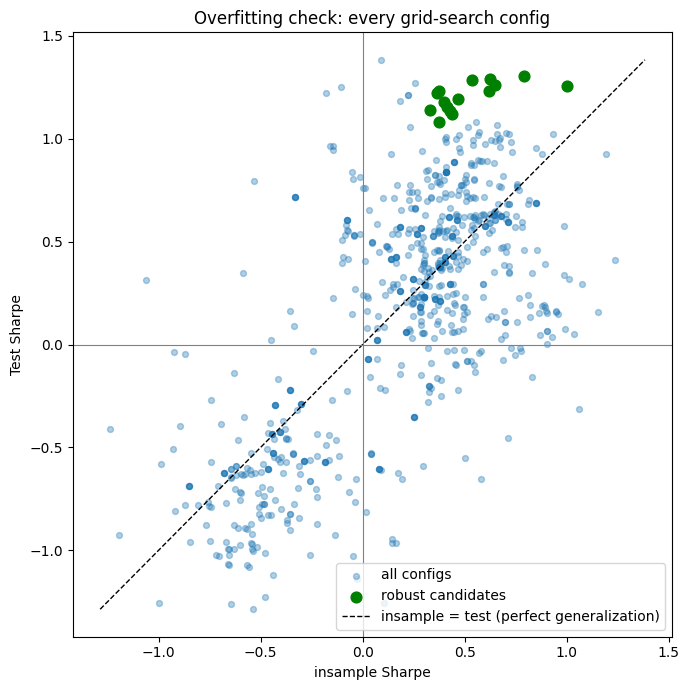

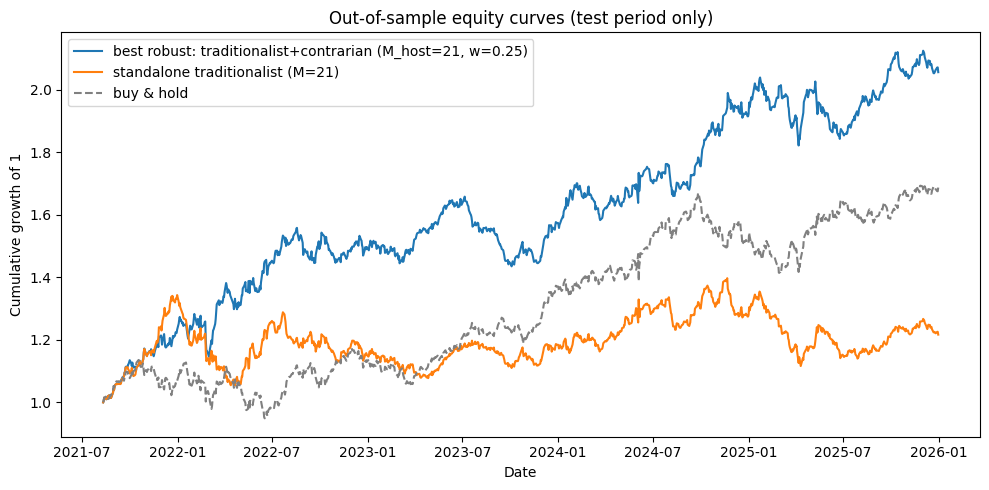

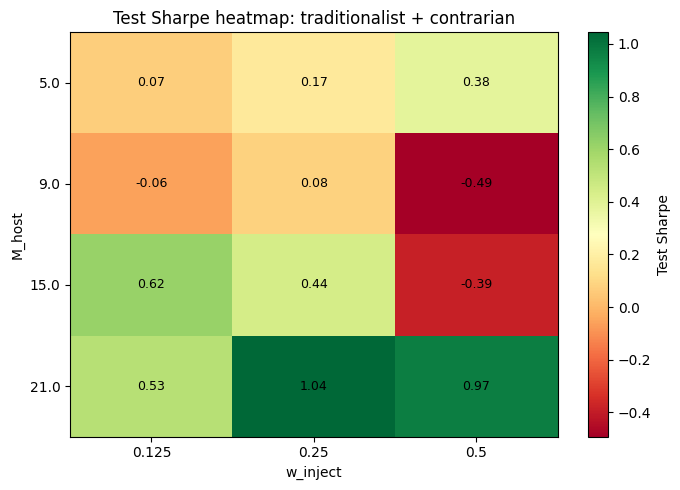

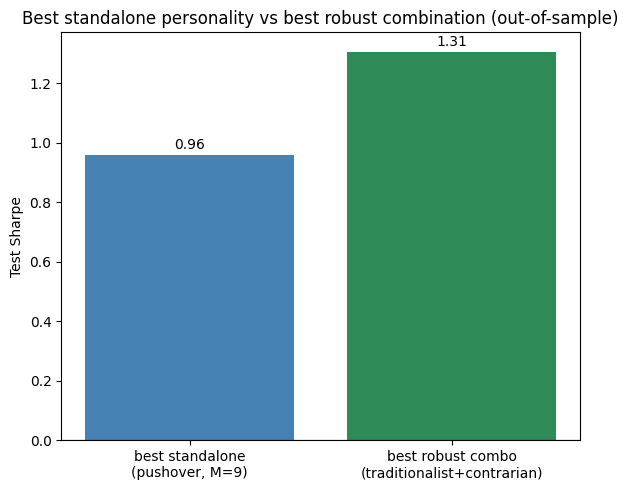

In [6]:
# %% [markdown]
# ## CONFIG

# %%
import numpy as np
import pandas as pd
import itertools
import matplotlib.pyplot as plt

DATA_PATH = "/Users/anujkothari/BTP/Nifty1500_Final_Standardized/nifty50_tri.csv"   # <-- set this
DATE_COL = "timestamp"
CLOSE_COL = "close"

TREND_WINDOW = 200
B_OPPORTUNIST = 1.5
B_TRADITIONALIST = 0.7

HOST_TYPES = ["pushover", "opportunist", "traditionalist", "contrarian"]  # curmudgeon has no queue, can't be a host
INFLUENCER_TYPES = ["pushover", "opportunist", "traditionalist", "contrarian", "curmudgeon"]

M_SWEEP = [5, 9, 15, 21]
W_INJECT_SWEEP = [0.0, 0.125, 0.25, 0.5]
SEED = 0
ANNUALIZATION = 252
insample_FRACTION = 0.6
TOP_K = 15

# %% [markdown]
# ## Data

# %%
def load_returns(path=DATA_PATH, date_col=DATE_COL, close_col=CLOSE_COL):
    df = pd.read_csv(path)
    df[date_col] = pd.to_datetime(df[date_col])
    df = df.sort_values(date_col).reset_index(drop=True)
    df["ret"] = df[close_col].pct_change()
    df["q"] = np.sign(df["ret"])
    df.loc[df["q"] == 0, "q"] = 1.0
    df = df.dropna(subset=["ret"]).reset_index(drop=True)
    return df.rename(columns={date_col: "date", close_col: "close"})


def build_lagged_q(df, lag_days=1):
    df = df.copy()
    df["q_lagged"] = df["q"].shift(lag_days)
    return df

# %% [markdown]
# ## Vectorized weighted-memory kernel

# %%
def _rolling_weighted_sign(vals, M, weights):
    n = len(vals)
    out = np.full(n, np.nan)
    if n >= M:
        windows = np.lib.stride_tricks.sliding_window_view(vals, M)
        valid = ~np.isnan(windows).any(axis=1)
        sigma = windows @ weights
        sigma_full = np.full(windows.shape[0], np.nan)
        sigma_full[valid] = sigma[valid]
        out[M - 1:] = sigma_full
    sign = np.sign(out)
    sign[sign == 0] = 1.0
    return sign


def build_personality_signal(ptype, q_market, M=None, b=None, curmudgeon_bias=None):
    if ptype == "pushover":
        return _rolling_weighted_sign(q_market, M, np.ones(M))
    elif ptype == "opportunist":
        b = b if b is not None else B_OPPORTUNIST
        return _rolling_weighted_sign(q_market, M, b ** np.arange(M))
    elif ptype == "traditionalist":
        b = b if b is not None else B_TRADITIONALIST
        return _rolling_weighted_sign(q_market, M, b ** np.arange(M))
    elif ptype == "contrarian":
        return -1.0 * _rolling_weighted_sign(q_market, M, np.ones(M))
    elif ptype == "curmudgeon":
        return curmudgeon_bias.copy()
    else:
        raise ValueError(f"unknown personality type: {ptype}")

# %% [markdown]
# ## One-directional injection

# %%
def build_host_signal_with_injection(host_type, influencer_type, q_market, curmudgeon_bias,
                                      M_host, M_influencer, w_inject, seed=SEED):
    influencer_signal = build_personality_signal(
        influencer_type, q_market, M=M_influencer, curmudgeon_bias=curmudgeon_bias
    )
    influencer_signal_lagged = np.roll(influencer_signal, 1)
    influencer_signal_lagged[0] = np.nan

    rng = np.random.RandomState(seed)
    inject_mask = rng.rand(len(q_market)) < w_inject

    observed_bit = np.where(inject_mask, influencer_signal_lagged, q_market)
    fallback = np.isnan(observed_bit)
    observed_bit[fallback] = q_market[fallback]

    if host_type == "pushover":
        return _rolling_weighted_sign(observed_bit, M_host, np.ones(M_host))
    elif host_type == "opportunist":
        return _rolling_weighted_sign(observed_bit, M_host, B_OPPORTUNIST ** np.arange(M_host))
    elif host_type == "traditionalist":
        return _rolling_weighted_sign(observed_bit, M_host, B_TRADITIONALIST ** np.arange(M_host))
    elif host_type == "contrarian":
        return -1.0 * _rolling_weighted_sign(observed_bit, M_host, np.ones(M_host))
    else:
        raise ValueError(f"{host_type} cannot be a host (no memory queue)")

# %% [markdown]
# ## Backtest

# %%
def backtest_signal(signal, ret):
    valid = ~np.isnan(signal) & ~np.isnan(ret)
    sig, r = signal[valid], ret[valid]
    if valid.sum() < 30:
        return {"sharpe": np.nan, "ann_return": np.nan, "ann_vol": np.nan,
                "max_drawdown": np.nan, "turnover": np.nan, "n_days": valid.sum()}
    strat_ret = sig * r
    equity = np.cumprod(1 + strat_ret)
    ann_return = strat_ret.mean() * ANNUALIZATION
    ann_vol = strat_ret.std() * np.sqrt(ANNUALIZATION)
    sharpe = ann_return / ann_vol if ann_vol > 0 else np.nan
    peak = np.maximum.accumulate(equity)
    max_dd = ((equity - peak) / peak).min()
    turnover = (np.diff(sig) != 0).mean()
    return {"sharpe": sharpe, "ann_return": ann_return, "ann_vol": ann_vol,
            "max_drawdown": max_dd, "turnover": turnover, "n_days": valid.sum()}

# %% [markdown]
# ## Sanity checks

# %%
def run_sanity_checks(q_market, curmudgeon_bias):
    for host_type in HOST_TYPES:
        standalone = build_personality_signal(host_type, q_market, M=9)
        injected_zero = build_host_signal_with_injection(
            host_type, "curmudgeon", q_market, curmudgeon_bias, M_host=9, M_influencer=9, w_inject=0.0
        )
        valid = ~np.isnan(standalone) & ~np.isnan(injected_zero)
        assert np.array_equal(standalone[valid], injected_zero[valid]), \
            f"w_inject=0 should exactly match standalone {host_type}"
    print("Sanity checks passed: w_inject=0 reduces exactly to standalone personality.")

# %% [markdown]
# ## Grid search with insample/test split

# %%
def run_grid_search():
    df = load_returns()
    df = build_lagged_q(df)
    q_market = df["q_lagged"].values
    ret = df["ret"].values

    trend_slope = df["close"].rolling(TREND_WINDOW).mean().diff().shift(1).values
    curmudgeon_bias = np.sign(trend_slope)
    curmudgeon_bias[curmudgeon_bias == 0] = 1.0
    curmudgeon_bias[np.isnan(trend_slope)] = np.nan

    run_sanity_checks(q_market, curmudgeon_bias)

    n = len(df)
    split = int(n * insample_FRACTION)
    print(f"\ninsample: {df['date'].iloc[0].date()} to {df['date'].iloc[split-1].date()} ({split} days)")
    print(f"Test:  {df['date'].iloc[split].date()} to {df['date'].iloc[-1].date()} ({n-split} days)\n")

    records = []

    for host_type in HOST_TYPES + ["curmudgeon"]:
        for M in (M_SWEEP if host_type != "curmudgeon" else [None]):
            sig = build_personality_signal(host_type, q_market, M=M, curmudgeon_bias=curmudgeon_bias)
            insample_metrics = backtest_signal(sig[:split], ret[:split])
            test_metrics = backtest_signal(sig[split:], ret[split:])
            records.append({
                "host": host_type, "influencer": "none", "M_host": M, "M_influencer": None,
                "w_inject": 0.0,
                "insample_sharpe": insample_metrics["sharpe"], "test_sharpe": test_metrics["sharpe"],
                "insample_turnover": insample_metrics["turnover"], "test_turnover": test_metrics["turnover"],
                "insample_maxdd": insample_metrics["max_drawdown"], "test_maxdd": test_metrics["max_drawdown"],
            })

    for host_type, influencer_type in itertools.product(HOST_TYPES, INFLUENCER_TYPES):
        if host_type == influencer_type:
            continue
        for M_host, M_influencer, w in itertools.product(M_SWEEP, M_SWEEP, W_INJECT_SWEEP):
            if w == 0.0:
                continue
            sig = build_host_signal_with_injection(
                host_type, influencer_type, q_market, curmudgeon_bias,
                M_host=M_host, M_influencer=M_influencer, w_inject=w
            )
            insample_metrics = backtest_signal(sig[:split], ret[:split])
            test_metrics = backtest_signal(sig[split:], ret[split:])
            records.append({
                "host": host_type, "influencer": influencer_type,
                "M_host": M_host, "M_influencer": M_influencer, "w_inject": w,
                "insample_sharpe": insample_metrics["sharpe"], "test_sharpe": test_metrics["sharpe"],
                "insample_turnover": insample_metrics["turnover"], "test_turnover": test_metrics["turnover"],
                "insample_maxdd": insample_metrics["max_drawdown"], "test_maxdd": test_metrics["max_drawdown"],
            })

    return pd.DataFrame(records)


results = run_grid_search()
print(f"Total configs evaluated: {len(results)}\n")

# %% [markdown]
# ## Leaderboard — ranked by insample Sharpe

# %%
leaderboard = results.sort_values("insample_sharpe", ascending=False).head(TOP_K).copy()
leaderboard["sharpe_gap"] = leaderboard["insample_sharpe"] - leaderboard["test_sharpe"]

cols = ["host", "influencer", "M_host", "M_influencer", "w_inject",
        "insample_sharpe", "test_sharpe", "sharpe_gap", "insample_turnover", "test_turnover"]
print(leaderboard[cols].round(3).to_string(index=False))

suspicious = leaderboard[leaderboard["sharpe_gap"] > 0.5]
if len(suspicious) > 0:
    print(f"\n{len(suspicious)} of top {TOP_K} configs show insample-test Sharpe gap > 0.5 — likely overfit, not robust.")

# %% [markdown]
# ## Robust candidates: rank by TEST Sharpe among configs that were also decent in-sample
# BUG FIX: `robust` previously came from `results`, which never had `sharpe_gap`
# computed on it (only `leaderboard`, a separate copy, did) — that's what
# caused the KeyError. Now `sharpe_gap` is computed on `robust` directly.

# %%
robust = results[results["insample_sharpe"] > 0.3].sort_values("test_sharpe", ascending=False).head(TOP_K).copy()
robust["sharpe_gap"] = robust["insample_sharpe"] - robust["test_sharpe"]
print(robust[cols].round(3).to_string(index=False))

# %% [markdown]
# ## Graph 1 — insample Sharpe vs Test Sharpe for every config
# Points on the diagonal generalized well (insample ≈ test). Points far below the
# line (high insample, low/negative test) are the overfit configs — good only by
# chance on the insampleing slice.

# %%
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(results["insample_sharpe"], results["test_sharpe"], alpha=0.35, s=18, label="all configs")
ax.scatter(robust["insample_sharpe"], robust["test_sharpe"], color="green", s=60,
           label="robust candidates", zorder=5)
lims = [min(results["insample_sharpe"].min(), results["test_sharpe"].min()),
        max(results["insample_sharpe"].max(), results["test_sharpe"].max())]
ax.plot(lims, lims, "k--", linewidth=1, label="insample = test (perfect generalization)")
ax.axhline(0, color="gray", linewidth=0.8)
ax.axvline(0, color="gray", linewidth=0.8)
ax.set_xlabel("insample Sharpe")
ax.set_ylabel("Test Sharpe")
ax.set_title("Overfitting check: every grid-search config")
ax.legend()
plt.tight_layout()
plt.show()

# %% [markdown]
# ## Graph 2 — Best robust config's equity curve vs standalone host and buy-and-hold
# Built on the TEST period only.

# %%
def rebuild_signal(row, q_market, curmudgeon_bias):
    if row["influencer"] == "none":
        return build_personality_signal(row["host"], q_market, M=row["M_host"], curmudgeon_bias=curmudgeon_bias)
    return build_host_signal_with_injection(
        row["host"], row["influencer"], q_market, curmudgeon_bias,
        M_host=int(row["M_host"]), M_influencer=int(row["M_influencer"]), w_inject=row["w_inject"]
    )


df = load_returns()
df = build_lagged_q(df)
q_market = df["q_lagged"].values
ret = df["ret"].values
trend_slope = df["close"].rolling(TREND_WINDOW).mean().diff().shift(1).values
curmudgeon_bias = np.sign(trend_slope)
curmudgeon_bias[curmudgeon_bias == 0] = 1.0
curmudgeon_bias[np.isnan(trend_slope)] = np.nan

n = len(df)
split = int(n * insample_FRACTION)

best_row = robust.iloc[0]
best_signal = rebuild_signal(best_row, q_market, curmudgeon_bias)
host_only_signal = build_personality_signal(best_row["host"], q_market, M=int(best_row["M_host"]))

test_dates = df["date"].values[split:]
test_ret = ret[split:]

combo_equity = np.cumprod(1 + best_signal[split:] * test_ret)
host_equity = np.cumprod(1 + host_only_signal[split:] * test_ret)
buyhold_equity = np.cumprod(1 + test_ret)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(test_dates, combo_equity,
        label=f"best robust: {best_row['host']}+{best_row['influencer']} "
              f"(M_host={int(best_row['M_host'])}, w={best_row['w_inject']})")
ax.plot(test_dates, host_equity, label=f"standalone {best_row['host']} (M={int(best_row['M_host'])})")
ax.plot(test_dates, buyhold_equity, label="buy & hold", linestyle="--", color="gray")
ax.set_title("Out-of-sample equity curves (test period only)")
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative growth of 1")
ax.legend()
plt.tight_layout()
plt.show()

# %% [markdown]
# ## Graph 3 — Heatmap: Test Sharpe across M_host and w_inject for the best pair

# %%
best_pair = results[(results["host"] == best_row["host"]) & (results["influencer"] == best_row["influencer"])]
pivot = best_pair.pivot_table(index="M_host", columns="w_inject", values="test_sharpe", aggfunc="mean")

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(pivot.values, cmap="RdYlGn", aspect="auto")
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
ax.set_xlabel("w_inject")
ax.set_ylabel("M_host")
ax.set_title(f"Test Sharpe heatmap: {best_row['host']} + {best_row['influencer']}")
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        val = pivot.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=9)
plt.colorbar(im, ax=ax, label="Test Sharpe")
plt.tight_layout()
plt.show()

# %% [markdown]
# ## Graph 4 — Best standalone personality vs best robust combo (test Sharpe)

# %%
standalone_best = results[results["influencer"] == "none"].sort_values("test_sharpe", ascending=False).iloc[0]
combo_best = robust.iloc[0]

fig, ax = plt.subplots(figsize=(6, 5))
labels = [f"best standalone\n({standalone_best['host']}, M={int(standalone_best['M_host'])})",
          f"best robust combo\n({combo_best['host']}+{combo_best['influencer']})"]
values = [standalone_best["test_sharpe"], combo_best["test_sharpe"]]
ax.bar(labels, values, color=["steelblue", "seagreen"])
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("Test Sharpe")
ax.set_title("Best standalone personality vs best robust combination (out-of-sample)")
for i, v in enumerate(values):
    ax.text(i, v + (0.02 if v >= 0 else -0.06), f"{v:.2f}", ha="center")
plt.tight_layout()
plt.show()

Sanity checks passed: w_inject=0 reduces exactly to standalone personality.

Train: 1990-01-02 to 2010-11-17 (6028 days)
Test:  2010-11-18 to 2026-04-02 (4019 days)

Total configs evaluated: 785

       host     influencer  M_host  M_influencer  w_inject  train_sharpe  test_sharpe  sharpe_gap  train_turnover  test_turnover
   pushover traditionalist     9.0           9.0     0.125         0.663        0.367       0.296           0.094          0.113
opportunist traditionalist     9.0          21.0     0.250         0.640        0.098       0.542           0.290          0.331
opportunist           none     9.0           NaN     0.000         0.637        0.365       0.272           0.305          0.332
opportunist traditionalist    15.0          21.0     0.250         0.630        0.196       0.434           0.289          0.329
opportunist traditionalist    21.0          21.0     0.250         0.627        0.193       0.434           0.290          0.329
opportunist           none    

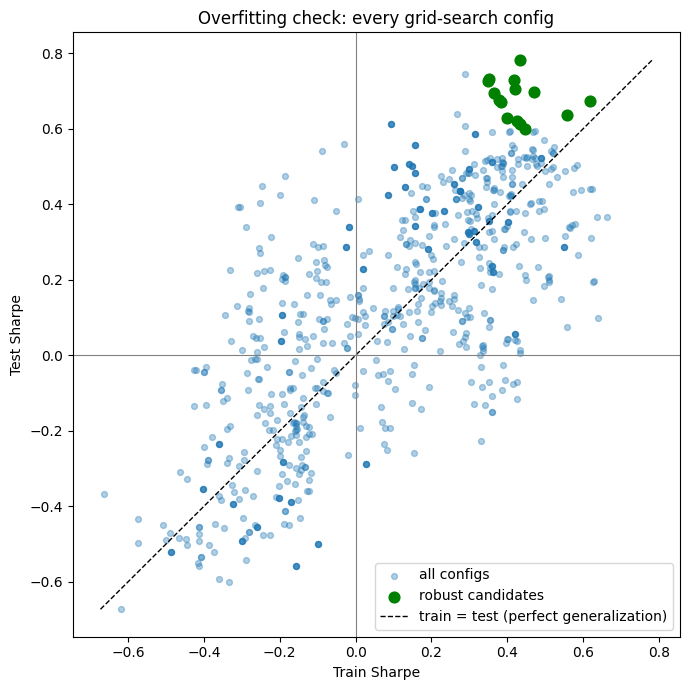

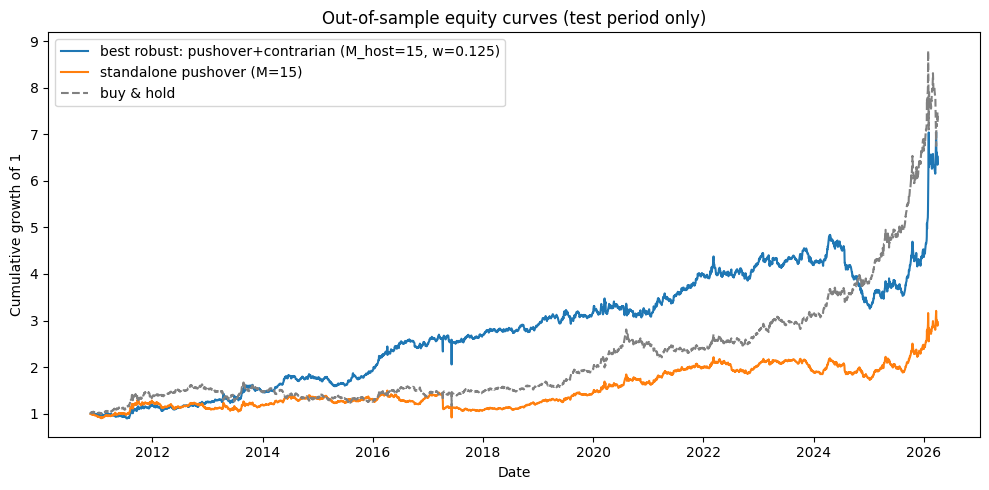

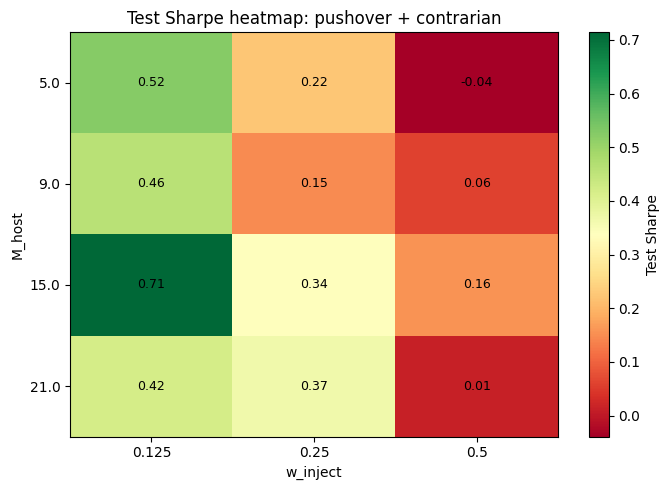

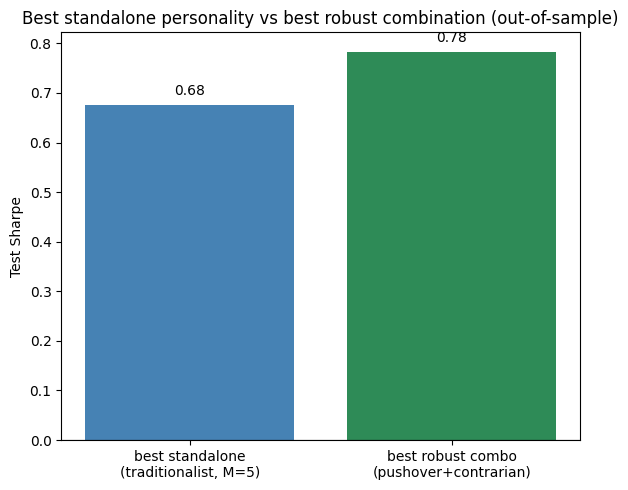

In [7]:
# %% [markdown]
# ## CONFIG

# %%
import numpy as np
import pandas as pd
import itertools
import matplotlib.pyplot as plt

DATA_PATH = "/Users/anujkothari/BTP/Gold.csv"   # <-- set this
DATE_COL = "timestamp"
CLOSE_COL = "close"

TREND_WINDOW = 200
B_OPPORTUNIST = 1.5
B_TRADITIONALIST = 0.7

HOST_TYPES = ["pushover", "opportunist", "traditionalist", "contrarian"]  # curmudgeon has no queue, can't be a host
INFLUENCER_TYPES = ["pushover", "opportunist", "traditionalist", "contrarian", "curmudgeon"]

M_SWEEP = [5, 9, 15, 21]
W_INJECT_SWEEP = [0.0, 0.125, 0.25, 0.5]
SEED = 0
ANNUALIZATION = 252
TRAIN_FRACTION = 0.6
TOP_K = 15

# %% [markdown]
# ## Data

# %%
def load_returns(path=DATA_PATH, date_col=DATE_COL, close_col=CLOSE_COL):
    df = pd.read_csv(path)
    df[date_col] = pd.to_datetime(df[date_col])
    df = df.sort_values(date_col).reset_index(drop=True)
    df["ret"] = df[close_col].pct_change()
    df["q"] = np.sign(df["ret"])
    df.loc[df["q"] == 0, "q"] = 1.0
    df = df.dropna(subset=["ret"]).reset_index(drop=True)
    return df.rename(columns={date_col: "date", close_col: "close"})


def build_lagged_q(df, lag_days=1):
    df = df.copy()
    df["q_lagged"] = df["q"].shift(lag_days)
    return df

# %% [markdown]
# ## Vectorized weighted-memory kernel

# %%
def _rolling_weighted_sign(vals, M, weights):
    n = len(vals)
    out = np.full(n, np.nan)
    if n >= M:
        windows = np.lib.stride_tricks.sliding_window_view(vals, M)
        valid = ~np.isnan(windows).any(axis=1)
        sigma = windows @ weights
        sigma_full = np.full(windows.shape[0], np.nan)
        sigma_full[valid] = sigma[valid]
        out[M - 1:] = sigma_full
    sign = np.sign(out)
    sign[sign == 0] = 1.0
    return sign


def build_personality_signal(ptype, q_market, M=None, b=None, curmudgeon_bias=None):
    if ptype == "pushover":
        return _rolling_weighted_sign(q_market, M, np.ones(M))
    elif ptype == "opportunist":
        b = b if b is not None else B_OPPORTUNIST
        return _rolling_weighted_sign(q_market, M, b ** np.arange(M))
    elif ptype == "traditionalist":
        b = b if b is not None else B_TRADITIONALIST
        return _rolling_weighted_sign(q_market, M, b ** np.arange(M))
    elif ptype == "contrarian":
        return -1.0 * _rolling_weighted_sign(q_market, M, np.ones(M))
    elif ptype == "curmudgeon":
        return curmudgeon_bias.copy()
    else:
        raise ValueError(f"unknown personality type: {ptype}")

# %% [markdown]
# ## One-directional injection

# %%
def build_host_signal_with_injection(host_type, influencer_type, q_market, curmudgeon_bias,
                                      M_host, M_influencer, w_inject, seed=SEED):
    influencer_signal = build_personality_signal(
        influencer_type, q_market, M=M_influencer, curmudgeon_bias=curmudgeon_bias
    )
    influencer_signal_lagged = np.roll(influencer_signal, 1)
    influencer_signal_lagged[0] = np.nan

    rng = np.random.RandomState(seed)
    inject_mask = rng.rand(len(q_market)) < w_inject

    observed_bit = np.where(inject_mask, influencer_signal_lagged, q_market)
    fallback = np.isnan(observed_bit)
    observed_bit[fallback] = q_market[fallback]

    if host_type == "pushover":
        return _rolling_weighted_sign(observed_bit, M_host, np.ones(M_host))
    elif host_type == "opportunist":
        return _rolling_weighted_sign(observed_bit, M_host, B_OPPORTUNIST ** np.arange(M_host))
    elif host_type == "traditionalist":
        return _rolling_weighted_sign(observed_bit, M_host, B_TRADITIONALIST ** np.arange(M_host))
    elif host_type == "contrarian":
        return -1.0 * _rolling_weighted_sign(observed_bit, M_host, np.ones(M_host))
    else:
        raise ValueError(f"{host_type} cannot be a host (no memory queue)")

# %% [markdown]
# ## Backtest

# %%
def backtest_signal(signal, ret):
    valid = ~np.isnan(signal) & ~np.isnan(ret)
    sig, r = signal[valid], ret[valid]
    if valid.sum() < 30:
        return {"sharpe": np.nan, "ann_return": np.nan, "ann_vol": np.nan,
                "max_drawdown": np.nan, "turnover": np.nan, "n_days": valid.sum()}
    strat_ret = sig * r
    equity = np.cumprod(1 + strat_ret)
    ann_return = strat_ret.mean() * ANNUALIZATION
    ann_vol = strat_ret.std() * np.sqrt(ANNUALIZATION)
    sharpe = ann_return / ann_vol if ann_vol > 0 else np.nan
    peak = np.maximum.accumulate(equity)
    max_dd = ((equity - peak) / peak).min()
    turnover = (np.diff(sig) != 0).mean()
    return {"sharpe": sharpe, "ann_return": ann_return, "ann_vol": ann_vol,
            "max_drawdown": max_dd, "turnover": turnover, "n_days": valid.sum()}

# %% [markdown]
# ## Sanity checks

# %%
def run_sanity_checks(q_market, curmudgeon_bias):
    for host_type in HOST_TYPES:
        standalone = build_personality_signal(host_type, q_market, M=9)
        injected_zero = build_host_signal_with_injection(
            host_type, "curmudgeon", q_market, curmudgeon_bias, M_host=9, M_influencer=9, w_inject=0.0
        )
        valid = ~np.isnan(standalone) & ~np.isnan(injected_zero)
        assert np.array_equal(standalone[valid], injected_zero[valid]), \
            f"w_inject=0 should exactly match standalone {host_type}"
    print("Sanity checks passed: w_inject=0 reduces exactly to standalone personality.")

# %% [markdown]
# ## Grid search with train/test split

# %%
def run_grid_search():
    df = load_returns()
    df = build_lagged_q(df)
    q_market = df["q_lagged"].values
    ret = df["ret"].values

    trend_slope = df["close"].rolling(TREND_WINDOW).mean().diff().shift(1).values
    curmudgeon_bias = np.sign(trend_slope)
    curmudgeon_bias[curmudgeon_bias == 0] = 1.0
    curmudgeon_bias[np.isnan(trend_slope)] = np.nan

    run_sanity_checks(q_market, curmudgeon_bias)

    n = len(df)
    split = int(n * TRAIN_FRACTION)
    print(f"\nTrain: {df['date'].iloc[0].date()} to {df['date'].iloc[split-1].date()} ({split} days)")
    print(f"Test:  {df['date'].iloc[split].date()} to {df['date'].iloc[-1].date()} ({n-split} days)\n")

    records = []

    for host_type in HOST_TYPES + ["curmudgeon"]:
        for M in (M_SWEEP if host_type != "curmudgeon" else [None]):
            sig = build_personality_signal(host_type, q_market, M=M, curmudgeon_bias=curmudgeon_bias)
            train_metrics = backtest_signal(sig[:split], ret[:split])
            test_metrics = backtest_signal(sig[split:], ret[split:])
            records.append({
                "host": host_type, "influencer": "none", "M_host": M, "M_influencer": None,
                "w_inject": 0.0,
                "train_sharpe": train_metrics["sharpe"], "test_sharpe": test_metrics["sharpe"],
                "train_turnover": train_metrics["turnover"], "test_turnover": test_metrics["turnover"],
                "train_maxdd": train_metrics["max_drawdown"], "test_maxdd": test_metrics["max_drawdown"],
            })

    for host_type, influencer_type in itertools.product(HOST_TYPES, INFLUENCER_TYPES):
        if host_type == influencer_type:
            continue
        for M_host, M_influencer, w in itertools.product(M_SWEEP, M_SWEEP, W_INJECT_SWEEP):
            if w == 0.0:
                continue
            sig = build_host_signal_with_injection(
                host_type, influencer_type, q_market, curmudgeon_bias,
                M_host=M_host, M_influencer=M_influencer, w_inject=w
            )
            train_metrics = backtest_signal(sig[:split], ret[:split])
            test_metrics = backtest_signal(sig[split:], ret[split:])
            records.append({
                "host": host_type, "influencer": influencer_type,
                "M_host": M_host, "M_influencer": M_influencer, "w_inject": w,
                "train_sharpe": train_metrics["sharpe"], "test_sharpe": test_metrics["sharpe"],
                "train_turnover": train_metrics["turnover"], "test_turnover": test_metrics["turnover"],
                "train_maxdd": train_metrics["max_drawdown"], "test_maxdd": test_metrics["max_drawdown"],
            })

    return pd.DataFrame(records)


results = run_grid_search()
print(f"Total configs evaluated: {len(results)}\n")

# %% [markdown]
# ## Leaderboard — ranked by TRAIN Sharpe

# %%
leaderboard = results.sort_values("train_sharpe", ascending=False).head(TOP_K).copy()
leaderboard["sharpe_gap"] = leaderboard["train_sharpe"] - leaderboard["test_sharpe"]

cols = ["host", "influencer", "M_host", "M_influencer", "w_inject",
        "train_sharpe", "test_sharpe", "sharpe_gap", "train_turnover", "test_turnover"]
print(leaderboard[cols].round(3).to_string(index=False))

suspicious = leaderboard[leaderboard["sharpe_gap"] > 0.5]
if len(suspicious) > 0:
    print(f"\n{len(suspicious)} of top {TOP_K} configs show train-test Sharpe gap > 0.5 — likely overfit, not robust.")

# %% [markdown]
# ## Robust candidates: rank by TEST Sharpe among configs that were also decent in-sample
# BUG FIX: `robust` previously came from `results`, which never had `sharpe_gap`
# computed on it (only `leaderboard`, a separate copy, did) — that's what
# caused the KeyError. Now `sharpe_gap` is computed on `robust` directly.

# %%
robust = results[results["train_sharpe"] > 0.3].sort_values("test_sharpe", ascending=False).head(TOP_K).copy()
robust["sharpe_gap"] = robust["train_sharpe"] - robust["test_sharpe"]
print(robust[cols].round(3).to_string(index=False))

# %% [markdown]
# ## Graph 1 — Train Sharpe vs Test Sharpe for every config
# Points on the diagonal generalized well (train ≈ test). Points far below the
# line (high train, low/negative test) are the overfit configs — good only by
# chance on the training slice.

# %%
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(results["train_sharpe"], results["test_sharpe"], alpha=0.35, s=18, label="all configs")
ax.scatter(robust["train_sharpe"], robust["test_sharpe"], color="green", s=60,
           label="robust candidates", zorder=5)
lims = [min(results["train_sharpe"].min(), results["test_sharpe"].min()),
        max(results["train_sharpe"].max(), results["test_sharpe"].max())]
ax.plot(lims, lims, "k--", linewidth=1, label="train = test (perfect generalization)")
ax.axhline(0, color="gray", linewidth=0.8)
ax.axvline(0, color="gray", linewidth=0.8)
ax.set_xlabel("Train Sharpe")
ax.set_ylabel("Test Sharpe")
ax.set_title("Overfitting check: every grid-search config")
ax.legend()
plt.tight_layout()
plt.show()

# %% [markdown]
# ## Graph 2 — Best robust config's equity curve vs standalone host and buy-and-hold
# Built on the TEST period only.

# %%
def rebuild_signal(row, q_market, curmudgeon_bias):
    if row["influencer"] == "none":
        return build_personality_signal(row["host"], q_market, M=row["M_host"], curmudgeon_bias=curmudgeon_bias)
    return build_host_signal_with_injection(
        row["host"], row["influencer"], q_market, curmudgeon_bias,
        M_host=int(row["M_host"]), M_influencer=int(row["M_influencer"]), w_inject=row["w_inject"]
    )


df = load_returns()
df = build_lagged_q(df)
q_market = df["q_lagged"].values
ret = df["ret"].values
trend_slope = df["close"].rolling(TREND_WINDOW).mean().diff().shift(1).values
curmudgeon_bias = np.sign(trend_slope)
curmudgeon_bias[curmudgeon_bias == 0] = 1.0
curmudgeon_bias[np.isnan(trend_slope)] = np.nan

n = len(df)
split = int(n * TRAIN_FRACTION)

best_row = robust.iloc[0]
best_signal = rebuild_signal(best_row, q_market, curmudgeon_bias)
host_only_signal = build_personality_signal(best_row["host"], q_market, M=int(best_row["M_host"]))

test_dates = df["date"].values[split:]
test_ret = ret[split:]

combo_equity = np.cumprod(1 + best_signal[split:] * test_ret)
host_equity = np.cumprod(1 + host_only_signal[split:] * test_ret)
buyhold_equity = np.cumprod(1 + test_ret)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(test_dates, combo_equity,
        label=f"best robust: {best_row['host']}+{best_row['influencer']} "
              f"(M_host={int(best_row['M_host'])}, w={best_row['w_inject']})")
ax.plot(test_dates, host_equity, label=f"standalone {best_row['host']} (M={int(best_row['M_host'])})")
ax.plot(test_dates, buyhold_equity, label="buy & hold", linestyle="--", color="gray")
ax.set_title("Out-of-sample equity curves (test period only)")
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative growth of 1")
ax.legend()
plt.tight_layout()
plt.show()

# %% [markdown]
# ## Graph 3 — Heatmap: Test Sharpe across M_host and w_inject for the best pair

# %%
best_pair = results[(results["host"] == best_row["host"]) & (results["influencer"] == best_row["influencer"])]
pivot = best_pair.pivot_table(index="M_host", columns="w_inject", values="test_sharpe", aggfunc="mean")

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(pivot.values, cmap="RdYlGn", aspect="auto")
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
ax.set_xlabel("w_inject")
ax.set_ylabel("M_host")
ax.set_title(f"Test Sharpe heatmap: {best_row['host']} + {best_row['influencer']}")
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        val = pivot.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=9)
plt.colorbar(im, ax=ax, label="Test Sharpe")
plt.tight_layout()
plt.show()

# %% [markdown]
# ## Graph 4 — Best standalone personality vs best robust combo (test Sharpe)

# %%
standalone_best = results[results["influencer"] == "none"].sort_values("test_sharpe", ascending=False).iloc[0]
combo_best = robust.iloc[0]

fig, ax = plt.subplots(figsize=(6, 5))
labels = [f"best standalone\n({standalone_best['host']}, M={int(standalone_best['M_host'])})",
          f"best robust combo\n({combo_best['host']}+{combo_best['influencer']})"]
values = [standalone_best["test_sharpe"], combo_best["test_sharpe"]]
ax.bar(labels, values, color=["steelblue", "seagreen"])
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("Test Sharpe")
ax.set_title("Best standalone personality vs best robust combination (out-of-sample)")
for i, v in enumerate(values):
    ax.text(i, v + (0.02 if v >= 0 else -0.06), f"{v:.2f}", ha="center")
plt.tight_layout()
plt.show()

Theoretical critical memory depth for eta=0.3: M_c = 9.82
Peer-interaction sanity checks passed.
All sanity checks passed.
M= 1  market-only: k=+0.9189 (single well )   peer(p=1.0): k=+0.6067 (single well )
M= 3  market-only: k=+0.3565 (single well )   peer(p=1.0): k=+0.2174 (single well )
M= 5  market-only: k=+0.2077 (single well )   peer(p=1.0): k=+0.1304 (single well )
M= 7  market-only: k=+0.1380 (single well )   peer(p=1.0): k=+0.0442 (single well )
M= 9  market-only: k=+0.1147 (single well )   peer(p=1.0): k=+0.0117 (single well )
M=11  market-only: k=+0.0790 (single well )   peer(p=1.0): k=-0.0329 (double well)
M=13  market-only: k=+0.0881 (single well )   peer(p=1.0): k=-0.0555 (double well)
M=15  market-only: k=+0.0678 (single well )   peer(p=1.0): k=-0.0642 (double well)
M=17  market-only: k=+0.0633 (single well )   peer(p=1.0): k=-0.0782 (double well)
M=19  market-only: k=+0.0601 (single well )   peer(p=1.0): insufficient data
M=21  market-only: k=+0.0484 (single well )   pe

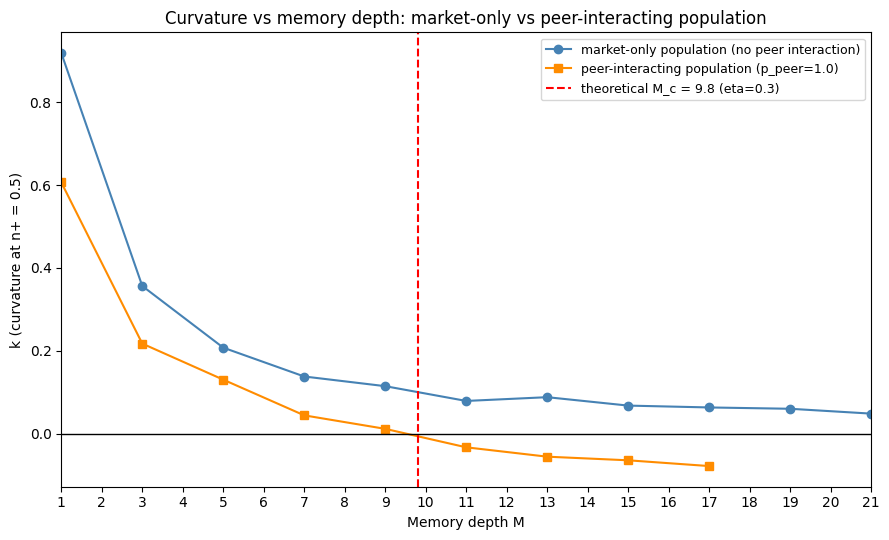

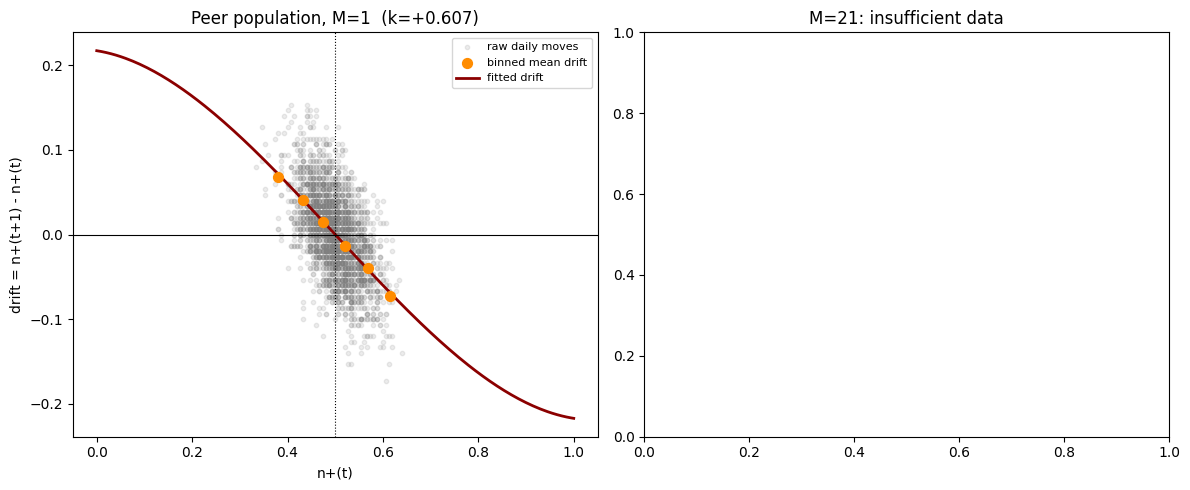

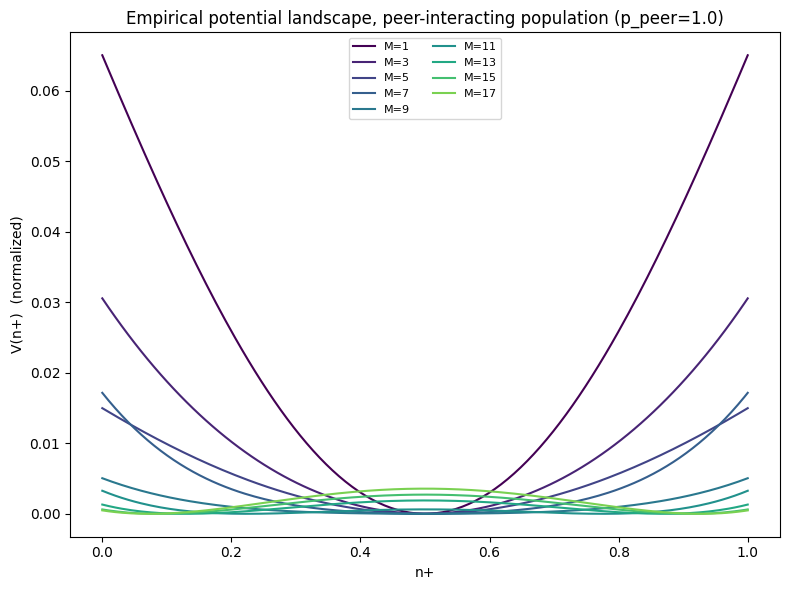

CONCLUSIONS
1. MARKET-ONLY population (each seed independently reads a noisy copy
   of the same market signal, no agent-to-agent interaction):
   -> k never went negative across M=[1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21].
      This is expected, not a bug: with no channel for one seed's opinion
      to influence another's, there is no feedback loop to amplify noise into
      self-reinforcing bias. N independent noisy readings of one external
      signal will mechanically average back toward the 'true' majority,
      which is a single-well (mean-reverting) result by construction.

2. PEER-INTERACTING population (each seed sometimes observes another
   agent's current opinion instead of the market, p_peer=1.0):
   -> k crosses zero between M=9 and M=11.
      Theoretical prediction (eta=0.3): M_c = 9.8.
      -> Empirical crossing BRACKETS the theoretical M_c -- consistent with the paper.

3. Practical reading for trading (based on whichever population actually
   showed a crossing a

In [7]:
# %% [markdown]
# ## CONFIG

# %%
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_PATH = "/Users/anujkothari/BTP/Nifty1500_Final_Standardized/nifty50_tri.csv"   # <-- set this
DATE_COL = "timestamp"
CLOSE_COL = "close"

ETA = 0.3            # per-agent observation noise (matches paper's measured 30% detection error)
N_SEEDS = 150         # number of synthetic agents in the Monte Carlo population
M_LIST = [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21]   # memory depths to sweep, same range as paper's Fig. 2
P_PEER = 1.0          # probability a given day's observation is a peer's opinion instead of the market
                       # (1.0 matches the paper's own assumption of pure peer-to-peer collisions;
                       #  lower values dilute the effect -- see Graph 1 and conclusions below)
N_BINS = 20           # bins for the empirical drift function
RANDOM_SEED = 0

THEORETICAL_MC = np.pi / (2 * (1 - 2 * ETA) ** 2)
print(f"Theoretical critical memory depth for eta={ETA}: M_c = {THEORETICAL_MC:.2f}")

# %% [markdown]
# ## Data

# %%
def load_returns(path=DATA_PATH, date_col=DATE_COL, close_col=CLOSE_COL):
    df = pd.read_csv(path)
    df[date_col] = pd.to_datetime(df[date_col])
    df = df.sort_values(date_col).reset_index(drop=True)
    df["ret"] = df[close_col].pct_change()
    df["q"] = np.sign(df["ret"])
    df.loc[df["q"] == 0, "q"] = 1.0
    df = df.dropna(subset=["ret"]).reset_index(drop=True)
    return df.rename(columns={date_col: "date", close_col: "close"})


def build_lagged_q(df, lag_days=1):
    df = df.copy()
    df["q_lagged"] = df["q"].shift(lag_days)
    return df

# %% [markdown]
# ## Monte Carlo population: N_SEEDS synthetic agents, each with noisy observation of the
# real market's lagged return sign, each running a flat-weight ("pushover") memory of depth M.
# n_+(t) = fraction of agents voting +1 on day t.

# %%
def simulate_population_n_plus(q_market, M, eta, n_seeds, seed_base=RANDOM_SEED):
    n_days = len(q_market)
    rng = np.random.RandomState(seed_base)

    # each seed independently observes a noisy version of the same market sign each day
    flip_mask = rng.rand(n_seeds, n_days) < eta
    observed = np.tile(q_market, (n_seeds, 1))
    observed = np.where(flip_mask, -observed, observed)
    observed[np.isnan(np.tile(q_market, (n_seeds, 1)))] = np.nan

    windows = np.lib.stride_tricks.sliding_window_view(observed, window_shape=M, axis=1)  # (n_seeds, n_days-M+1, M)
    valid = ~np.isnan(windows).any(axis=2)
    sigma = windows.sum(axis=2)

    votes = np.full((n_seeds, n_days), np.nan)
    sign = np.sign(sigma)
    sign[sign == 0] = 1.0
    sign[~valid] = np.nan
    votes[:, M - 1:] = sign

    with np.errstate(invalid="ignore"):
        n_plus = np.nanmean(votes == 1.0, axis=0)
    n_plus[np.isnan(votes).all(axis=0)] = np.nan
    return n_plus


# %% [markdown]
# ## Peer-interacting population (the mechanistically correct version)
#
# Unlike the version above, where every seed only ever reads a noisy copy of
# the SAME market signal (no way for one seed's opinion to affect another's),
# here each seed's queue receives, on each day, EITHER the market's lagged
# sign OR a randomly-sampled OTHER agent's current opinion, mean-field style:
# a peer's opinion is drawn as +1 with probability n+(t-1), the population's
# own fraction from the previous day. This closes the feedback loop the
# paper's V(n+) formula actually depends on -- one agent's bias can spread
# to others, and vice versa.
#
# Requires a day-by-day loop (population state depends on its own history),
# but each day's update is vectorized across all seeds.

# %%
def simulate_population_n_plus_peer(q_market, M, eta, p_peer, n_seeds, seed_base=RANDOM_SEED):
    n_days = len(q_market)
    rng = np.random.RandomState(seed_base)
    buffer = np.zeros((n_seeds, M))
    n_plus_series = np.full(n_days, np.nan)

    for t in range(n_days):
        if np.isnan(q_market[t]):
            continue
        pos = t % M

        if t < M:
            # not enough queue history yet for a meaningful peer signal -> market only
            use_peer = np.zeros(n_seeds, dtype=bool)
            peer_bit = np.zeros(n_seeds)
        else:
            prev_n_plus = n_plus_series[t - 1]  # guaranteed defined once t >= M
            use_peer = rng.rand(n_seeds) < p_peer
            peer_bit = np.where(rng.rand(n_seeds) < prev_n_plus, 1.0, -1.0)

        market_bit = np.full(n_seeds, q_market[t])
        raw_bit = np.where(use_peer, peer_bit, market_bit)

        flip = rng.rand(n_seeds) < eta
        new_bit = np.where(flip, -raw_bit, raw_bit)

        buffer[:, pos] = new_bit

        if t >= M - 1:
            sigma = buffer.sum(axis=1)
            opinions = np.sign(sigma)
            opinions[opinions == 0] = 1.0
            n_plus_series[t] = np.mean(opinions == 1.0)

    return n_plus_series

# %% [markdown]
# ## Sanity checks

# %%
def run_sanity_checks():
    q_test = np.array([1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0])

    # eta=0 (no noise), all agents see the same thing -> n_plus should be exactly 0 or 1 everywhere valid
    n_plus_no_noise = simulate_population_n_plus(q_test, M=3, eta=0.0, n_seeds=50)
    valid_vals = n_plus_no_noise[~np.isnan(n_plus_no_noise)]
    assert np.all((valid_vals == 0.0) | (valid_vals == 1.0)), "eta=0 should give unanimous population every day"
    assert np.all(valid_vals == 1.0), "all-up market with eta=0 should give unanimous +1 population"

    # eta=0.5 (pure coin-flip noise) should give n_plus scattered around 0.5, not stuck at 0/1
    n_plus_full_noise = simulate_population_n_plus(q_test, M=1, eta=0.5, n_seeds=2000)
    valid_full = n_plus_full_noise[~np.isnan(n_plus_full_noise)]
    assert abs(valid_full.mean() - 0.5) < 0.05, "eta=0.5 should average close to 0.5 across a large population"

    print("All sanity checks passed.")


def run_peer_sanity_checks():
    q_up = np.ones(60)

    # p_peer=0 should behave identically to the no-peer version (same underlying mechanism,
    # market-only every day)
    n_plus_peer_zero = simulate_population_n_plus_peer(q_up, M=3, eta=0.0, p_peer=0.0, n_seeds=50)
    valid = n_plus_peer_zero[~np.isnan(n_plus_peer_zero)]
    assert np.all(valid == 1.0), "p_peer=0, eta=0, all-up market should give unanimous +1 population"

    # p_peer=1, eta=0: pure echo chamber. Once agents stop looking at the market at all,
    # whatever the population's opinion happens to be should self-reinforce and stay locked
    # (variance should collapse to ~0 in the later part of the series)
    n_plus_echo = simulate_population_n_plus_peer(q_up, M=5, eta=0.0, p_peer=1.0, n_seeds=200, seed_base=1)
    valid_echo = n_plus_echo[~np.isnan(n_plus_echo)]
    late_half = valid_echo[len(valid_echo) // 2:]
    assert late_half.std() < 0.05, "pure echo chamber (p_peer=1, eta=0) should lock into a stable consensus"

    print("Peer-interaction sanity checks passed.")


run_peer_sanity_checks()


run_sanity_checks()

# %% [markdown]
# ## Empirical drift function: how does n_+ tend to move from wherever it currently is?
# drift(n+) = average of [n+(t+1) - n+(t)] conditional on n+(t) landing in a given bin.
# Fit drift(x) = a1*x + a3*x^3, x = n+ - 0.5 (odd terms only, matching the paper's symmetric
# potential form). Then k = -a1 (curvature at center), c = -a3.
# V(x) = (k/2)*x^2 + (c/4)*x^4  since drift = -dV/dx.

# %%
def fit_drift_and_potential(n_plus, n_bins=N_BINS):
    x = n_plus[:-1] - 0.5
    dx = n_plus[1:] - n_plus[:-1]
    valid = ~np.isnan(x) & ~np.isnan(dx)
    x, dx = x[valid], dx[valid]

    if len(x) < 30:
        return None  # not enough data to fit reliably

    bin_edges = np.linspace(-0.5, 0.5, n_bins + 1)
    bin_idx = np.digitize(x, bin_edges) - 1
    bin_centers, bin_drift = [], []
    for b in range(n_bins):
        mask = bin_idx == b
        if mask.sum() >= 5:  # require a minimum number of observations per bin
            bin_centers.append(x[mask].mean())
            bin_drift.append(dx[mask].mean())
    bin_centers = np.array(bin_centers)
    bin_drift = np.array(bin_drift)

    if len(bin_centers) < 4:
        return None

    design = np.column_stack([bin_centers, bin_centers ** 3])
    coeffs, *_ = np.linalg.lstsq(design, bin_drift, rcond=None)
    a1, a3 = coeffs
    k, c = -a1, -a3

    return {
        "bin_centers": bin_centers, "bin_drift": bin_drift,
        "k": k, "c": c,
        "x_raw": x, "dx_raw": dx,
    }


def potential_V(x, k, c):
    return 0.5 * k * x ** 2 + 0.25 * c * x ** 4

# %% [markdown]
# ## Run the sweep across memory depths

# %%
df = load_returns()
df = build_lagged_q(df)
q_market = df["q_lagged"].values

sweep_results = {}
sweep_results_peer = {}
for M in M_LIST:
    n_plus = simulate_population_n_plus(q_market, M, ETA, N_SEEDS)
    fit = fit_drift_and_potential(n_plus)
    sweep_results[M] = {"n_plus": n_plus, "fit": fit}

    n_plus_peer = simulate_population_n_plus_peer(q_market, M, ETA, P_PEER, N_SEEDS)
    fit_peer = fit_drift_and_potential(n_plus_peer)
    sweep_results_peer[M] = {"n_plus": n_plus_peer, "fit": fit_peer}

    line = f"M={M:>2}  "
    if fit is not None:
        wt = "double well" if fit["k"] < 0 else "single well "
        line += f"market-only: k={fit['k']:+.4f} ({wt})   "
    else:
        line += "market-only: insufficient data   "
    if fit_peer is not None:
        wt_p = "double well" if fit_peer["k"] < 0 else "single well "
        line += f"peer(p={P_PEER}): k={fit_peer['k']:+.4f} ({wt_p})"
    else:
        line += f"peer(p={P_PEER}): insufficient data"
    print(line)

# %% [markdown]
# ## Graph 1 — k (curvature) vs memory depth M
# k > 0: population pulled back to 50/50 (single well).
# k < 0: population locks into one extreme (double well) — this is the memory-induced
# symmetry breaking the paper describes. The crossing point is the empirical M_c.

# %%
# Ms = [M for M in M_LIST if sweep_results[M]["fit"] is not None]
# ks = [sweep_results[M]["fit"]["k"] for M in Ms]

# Ms_peer = [M for M in M_LIST if sweep_results_peer[M]["fit"] is not None]
# ks_peer = [sweep_results_peer[M]["fit"]["k"] for M in Ms_peer]

# fig, ax = plt.subplots(figsize=(9, 5.5))
# ax.plot(Ms, ks, marker="o", color="steelblue", label="market-only population (no peer interaction)")
# ax.plot(Ms_peer, ks_peer, marker="s", color="darkorange", label=f"peer-interacting population (p_peer={P_PEER})")
# ax.axhline(0, color="black", linewidth=1)
# ax.axvline(THEORETICAL_MC, color="red", linestyle="--",
#            label=f"theoretical M_c = {THEORETICAL_MC:.1f} (eta={ETA})")
# ax.set_xlabel("Memory depth M")
# ax.set_ylabel("k (curvature at n+ = 0.5)")
# ax.set_title("Curvature vs memory depth: market-only vs peer-interacting population")
# ax.legend(fontsize=9)
# plt.tight_layout()
# plt.show()

from matplotlib.ticker import MultipleLocator

Ms = [M for M in M_LIST if sweep_results[M]["fit"] is not None]
ks = [sweep_results[M]["fit"]["k"] for M in Ms]

Ms_peer = [M for M in M_LIST if sweep_results_peer[M]["fit"] is not None]
ks_peer = [sweep_results_peer[M]["fit"]["k"] for M in Ms_peer]

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(Ms, ks, marker="o", color="steelblue", label="market-only population (no peer interaction)")
ax.plot(Ms_peer, ks_peer, marker="s", color="darkorange", label=f"peer-interacting population (p_peer={P_PEER})")
ax.axhline(0, color="black", linewidth=1)
ax.axvline(THEORETICAL_MC, color="red", linestyle="--",
           label=f"theoretical M_c = {THEORETICAL_MC:.1f} (eta={ETA})")

ax.set_xlabel("Memory depth M")
ax.set_ylabel("k (curvature at n+ = 0.5)")
ax.set_title("Curvature vs memory depth: market-only vs peer-interacting population")

# force integer ticks at every step of 1 (1,2,3,4,5,6,...)
ax.xaxis.set_major_locator(MultipleLocator(1))
ax.set_xlim(min(M_LIST), max(M_LIST))

ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

# %% [markdown]
# ## Graph 2 — Drift function drift(n+), PEER-INTERACTING population, small M vs large M
# Small M: drift always points back toward 0.5 (restoring force, like a spring).
# Large M: drift points AWAY from 0.5 near the center, toward the extremes (repelling force) --
# this is the signature of the paper's memory-induced bistability.

# %%
M_small = min(M_LIST)
M_large = max(M_LIST)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, M in zip(axes, [M_small, M_large]):
    fit = sweep_results_peer[M]["fit"]
    if fit is None:
        ax.set_title(f"M={M}: insufficient data")
        continue
    ax.scatter(fit["x_raw"] + 0.5, fit["dx_raw"], alpha=0.15, s=10, color="gray", label="raw daily moves")
    ax.scatter(fit["bin_centers"] + 0.5, fit["bin_drift"], color="darkorange", s=50, zorder=5, label="binned mean drift")
    x_fine = np.linspace(-0.5, 0.5, 200)
    fitted_drift = -(fit["k"] * x_fine + fit["c"] * x_fine ** 3)
    ax.plot(x_fine + 0.5, fitted_drift, color="darkred", linewidth=2, label="fitted drift")
    ax.axhline(0, color="black", linewidth=0.8)
    ax.axvline(0.5, color="black", linewidth=0.8, linestyle=":")
    ax.set_xlabel("n+(t)")
    ax.set_ylabel("drift = n+(t+1) - n+(t)")
    ax.set_title(f"Peer population, M={M}  (k={fit['k']:+.3f})")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

# %% [markdown]
# ## Graph 3 — the potential landscape V(n+), PEER-INTERACTING population, across several M
# Watch the bowl flatten and invert into a "W" as M crosses the critical value.

# %%
fig, ax = plt.subplots(figsize=(8, 6))
x_fine = np.linspace(-0.5, 0.5, 200)
colors = plt.cm.viridis(np.linspace(0, 1, len(M_LIST)))
for M, color in zip(M_LIST, colors):
    fit = sweep_results_peer[M]["fit"]
    if fit is None:
        continue
    V = potential_V(x_fine, fit["k"], fit["c"])
    V = V - V.min()  # normalize so every curve's floor is at 0, for visual comparison
    ax.plot(x_fine + 0.5, V, label=f"M={M}", color=color)
ax.set_xlabel("n+")
ax.set_ylabel("V(n+)  (normalized)")
ax.set_title(f"Empirical potential landscape, peer-interacting population (p_peer={P_PEER})")
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

# %% [markdown]
# ## Conclusions
# Auto-generated from the actual numbers above -- re-run this cell after changing DATA_PATH.

# %%
crossing_M = None
for i in range(len(Ms) - 1):
    if ks[i] >= 0 and ks[i + 1] < 0:
        crossing_M = (Ms[i], Ms[i + 1])
        break

crossing_M_peer = None
for i in range(len(Ms_peer) - 1):
    if ks_peer[i] >= 0 and ks_peer[i + 1] < 0:
        crossing_M_peer = (Ms_peer[i], Ms_peer[i + 1])
        break

print("=" * 70)
print("CONCLUSIONS")
print("=" * 70)

print("1. MARKET-ONLY population (each seed independently reads a noisy copy")
print("   of the same market signal, no agent-to-agent interaction):")
if crossing_M:
    print(f"   -> k crosses zero between M={crossing_M[0]} and M={crossing_M[1]}.")
else:
    print(f"   -> k never went negative across M={M_LIST}.")
    print("      This is expected, not a bug: with no channel for one seed's opinion")
    print("      to influence another's, there is no feedback loop to amplify noise into")
    print("      self-reinforcing bias. N independent noisy readings of one external")
    print("      signal will mechanically average back toward the 'true' majority,")
    print("      which is a single-well (mean-reverting) result by construction.")

print()
print("2. PEER-INTERACTING population (each seed sometimes observes another")
print(f"   agent's current opinion instead of the market, p_peer={P_PEER}):")
if crossing_M_peer:
    print(f"   -> k crosses zero between M={crossing_M_peer[0]} and M={crossing_M_peer[1]}.")
    print(f"      Theoretical prediction (eta={ETA}): M_c = {THEORETICAL_MC:.1f}.")
    if crossing_M_peer[0] <= THEORETICAL_MC <= crossing_M_peer[1]:
        print("      -> Empirical crossing BRACKETS the theoretical M_c -- consistent with the paper.")
    else:
        print("      -> Crossing found, but does not bracket the theoretical M_c exactly.")
        print("         Try sweeping p_peer -- the paper's formula assumes ALL collisions are")
        print("         peer-to-peer (p_peer=1 in our notation); lower p_peer dilutes the effect")
        print("         and should shift the empirical M_c higher than the theoretical value.")
else:
    print(f"   -> k never went negative across M={M_LIST} even with peer interaction enabled.")
    print(f"      Try increasing p_peer (closer to 1.0) or widening M_LIST -- with only")
    print(f"      p_peer={P_PEER} of collisions being peer-based, the amplification effect is")
    print(f"      weaker than the paper's fully-peer-collision assumption and may need a")
    print(f"      larger M to cross zero.")

print()
print("3. Practical reading for trading (based on whichever population actually")
print("   showed a crossing above):")
print("   - M values with k>0 (single well): the population signal is self-correcting --")
print("     it won't commit to a persistent directional stance. Expect choppier, more")
print("     mean-reverting behavior and higher turnover from a signal built at this M.")
print("   - M values with k<0 (double well): the population signal, once it leans one way,")
print("     tends to STAY that way until a large enough shock flips it. Expect stickier,")
print("     lower-turnover, more trend-persistent behavior at this M.")
print()
print("4. IMPORTANT CAVEATS before trusting this for real capital:")
print("   - eta and p_peer are ASSUMED parameters (eta matched to the paper's own measured")
print("     30%; p_peer is a free modeling choice), not estimated from Nifty data --")
print("     sensitivity-check both before drawing firm conclusions.")
print("   - The peer-interaction mean-field approximation (a 'peer' is a Bernoulli draw at")
print("     rate n+(t-1), not a literal second agent) is a simplification of the paper's")
print("     actual pairwise collision model. It captures the same feedback DIRECTION but")
print("     not the exact paper's population dynamics equation.")
print("   - Always re-run this on the specific date range you intend to trade -- the drift")
print("     fit reflects whatever autocorrelation structure is actually in that data.")

Theoretical critical memory depth (scale of 1) for eta=0.3: M_c = 19.63
Peer-interaction sanity checks passed.
All sanity checks passed.
M= 2  market-only: k=+0.9189 (single well )   peer(p=1.0): k=+0.6067 (single well )
M= 6  market-only: k=+0.3565 (single well )   peer(p=1.0): k=+0.2174 (single well )
M=10  market-only: k=+0.2077 (single well )   peer(p=1.0): k=+0.1304 (single well )
M=14  market-only: k=+0.1380 (single well )   peer(p=1.0): k=+0.0442 (single well )
M=18  market-only: k=+0.1147 (single well )   peer(p=1.0): k=+0.0117 (single well )
M=22  market-only: k=+0.0790 (single well )   peer(p=1.0): k=-0.0329 (double well)
M=26  market-only: k=+0.0881 (single well )   peer(p=1.0): k=-0.0555 (double well)
M=30  market-only: k=+0.0678 (single well )   peer(p=1.0): k=-0.0642 (double well)
M=34  market-only: k=+0.0633 (single well )   peer(p=1.0): k=-0.0782 (double well)
M=38  market-only: k=+0.0601 (single well )   peer(p=1.0): insufficient data
M=42  market-only: k=+0.0484 (sing

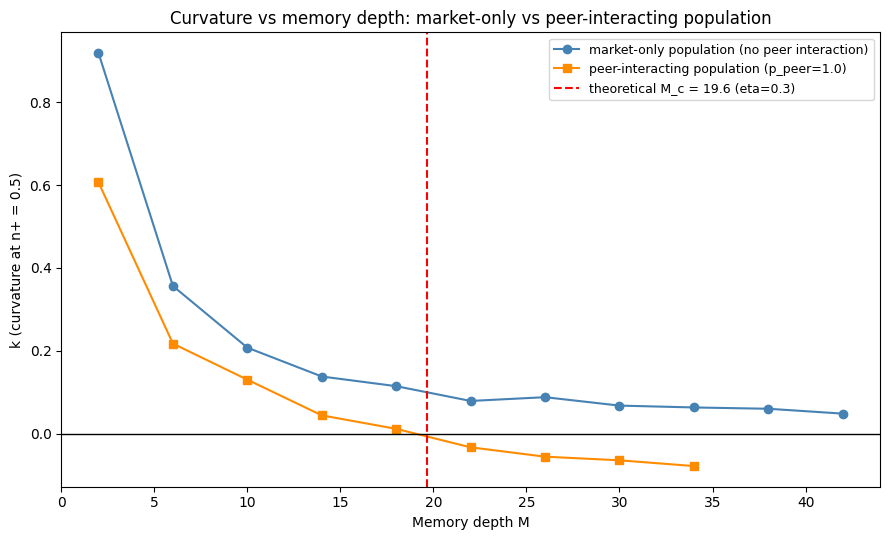

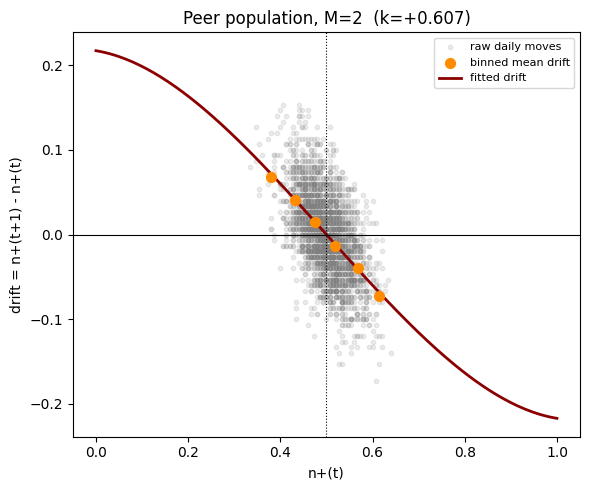

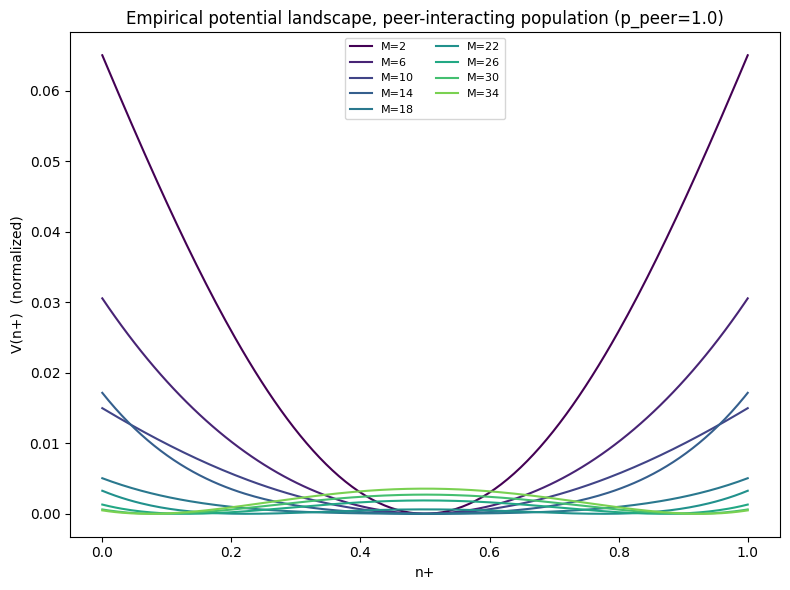

CONCLUSIONS (SCALE OF 1)
1. MARKET-ONLY population (each seed independently reads a noisy copy
   of the same market signal, no agent-to-agent interaction):
   -> k never went negative across M=[2, 6, 10, 14, 18, 22, 26, 30, 34, 38, 42].
      This is expected, not a bug: with no channel for one seed's opinion
      to influence another's, there is no feedback loop to amplify noise into
      self-reinforcing bias. N independent noisy readings of one external
      signal will mechanically average back toward the 'true' majority,
      which is a single-well (mean-reverting) result by construction.

2. PEER-INTERACTING population (each seed sometimes observes another
   agent's current opinion instead of the market, p_peer=1.0):
   -> k crosses zero between M=18 and M=22.
      Theoretical prediction (eta=0.3): M_c = 19.6.
      -> Empirical crossing BRACKETS the theoretical M_c -- consistent with the paper.

3. Practical reading for trading (based on whichever population actually
   s

In [9]:
# %% [markdown]
# ## CONFIG

# %%
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_PATH = "/Users/anujkothari/BTP/Nifty1500_Final_Standardized/nifty50_tri.csv"   # <-- set this
DATE_COL = "timestamp"
CLOSE_COL = "close"

ETA = 0.3            # per-agent observation noise (matches paper's measured 30% detection error)
N_SEEDS = 150         # number of synthetic agents in the Monte Carlo population
M_LIST = [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21]   # memory depths to sweep, same range as paper's Fig. 2
P_PEER = 1.0          # probability a given day's observation is a peer's opinion instead of the market
                       # (1.0 matches the paper's own assumption of pure peer-to-peer collisions;
                       #  lower values dilute the effect -- see Graph 1 and conclusions below)
N_BINS = 20           # bins for the empirical drift function
RANDOM_SEED = 0

# Scale of 1 formula (no division by 2 in the denominator)
THEORETICAL_MC = np.pi / ((1 - 2 * ETA) ** 2)
print(f"Theoretical critical memory depth (scale of 1) for eta={ETA}: M_c = {THEORETICAL_MC:.2f}")

# %% [markdown]
# ## Data

# %%
def load_returns(path=DATA_PATH, date_col=DATE_COL, close_col=CLOSE_COL):
    df = pd.read_csv(path)
    df[date_col] = pd.to_datetime(df[date_col])
    df = df.sort_values(date_col).reset_index(drop=True)
    df["ret"] = df[close_col].pct_change()
    df["q"] = np.sign(df["ret"])
    df.loc[df["q"] == 0, "q"] = 1.0
    df = df.dropna(subset=["ret"]).reset_index(drop=True)
    return df.rename(columns={date_col: "date", close_col: "close"})


def build_lagged_q(df, lag_days=1):
    df = df.copy()
    df["q_lagged"] = df["q"].shift(lag_days)
    return df

# %% [markdown]
# ## Monte Carlo population: N_SEEDS synthetic agents, each with noisy observation of the
# real market's lagged return sign, each running a flat-weight ("pushover") memory of depth M.
# n_+(t) = fraction of agents voting +1 on day t.

# %%
def simulate_population_n_plus(q_market, M, eta, n_seeds, seed_base=RANDOM_SEED):
    n_days = len(q_market)
    rng = np.random.RandomState(seed_base)

    # each seed independently observes a noisy version of the same market sign each day
    flip_mask = rng.rand(n_seeds, n_days) < eta
    observed = np.tile(q_market, (n_seeds, 1))
    observed = np.where(flip_mask, -observed, observed)
    observed[np.isnan(np.tile(q_market, (n_seeds, 1)))] = np.nan

    windows = np.lib.stride_tricks.sliding_window_view(observed, window_shape=M, axis=1)  # (n_seeds, n_days-M+1, M)
    valid = ~np.isnan(windows).any(axis=2)
    sigma = windows.sum(axis=2)

    votes = np.full((n_seeds, n_days), np.nan)
    sign = np.sign(sigma)
    sign[sign == 0] = 1.0
    sign[~valid] = np.nan
    votes[:, M - 1:] = sign

    with np.errstate(invalid="ignore"):
        n_plus = np.nanmean(votes == 1.0, axis=0)
    n_plus[np.isnan(votes).all(axis=0)] = np.nan
    return n_plus


# %% [markdown]
# ## Peer-interacting population (the mechanistically correct version)
#
# Unlike the version above, where every seed only ever reads a noisy copy of
# the SAME market signal (no way for one seed's opinion to affect another's),
# here each seed's queue receives, on each day, EITHER the market's lagged
# sign OR a randomly-sampled OTHER agent's current opinion, mean-field style:
# a peer's opinion is drawn as +1 with probability n+(t-1), the population's
# own fraction from the previous day. This closes the feedback loop the
# paper's V(n+) formula actually depends on -- one agent's bias can spread
# to others, and vice versa.
#
# Requires a day-by-day loop (population state depends on its own history),
# but each day's update is vectorized across all seeds.

# %%
def simulate_population_n_plus_peer(q_market, M, eta, p_peer, n_seeds, seed_base=RANDOM_SEED):
    n_days = len(q_market)
    rng = np.random.RandomState(seed_base)
    buffer = np.zeros((n_seeds, M))
    n_plus_series = np.full(n_days, np.nan)

    for t in range(n_days):
        if np.isnan(q_market[t]):
            continue
        pos = t % M

        if t < M:
            # not enough queue history yet for a meaningful peer signal -> market only
            use_peer = np.zeros(n_seeds, dtype=bool)
            peer_bit = np.zeros(n_seeds)
        else:
            prev_n_plus = n_plus_series[t - 1]  # guaranteed defined once t >= M
            use_peer = rng.rand(n_seeds) < p_peer
            peer_bit = np.where(rng.rand(n_seeds) < prev_n_plus, 1.0, -1.0)

        market_bit = np.full(n_seeds, q_market[t])
        raw_bit = np.where(use_peer, peer_bit, market_bit)

        flip = rng.rand(n_seeds) < eta
        new_bit = np.where(flip, -raw_bit, raw_bit)

        buffer[:, pos] = new_bit

        if t >= M - 1:
            sigma = buffer.sum(axis=1)
            opinions = np.sign(sigma)
            opinions[opinions == 0] = 1.0
            n_plus_series[t] = np.mean(opinions == 1.0)

    return n_plus_series

# %% [markdown]
# ## Sanity checks

# %%
def run_sanity_checks():
    q_test = np.array([1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0])

    # eta=0 (no noise), all agents see the same thing -> n_plus should be exactly 0 or 1 everywhere valid
    n_plus_no_noise = simulate_population_n_plus(q_test, M=3, eta=0.0, n_seeds=50)
    valid_vals = n_plus_no_noise[~np.isnan(n_plus_no_noise)]
    assert np.all((valid_vals == 0.0) | (valid_vals == 1.0)), "eta=0 should give unanimous population every day"
    assert np.all(valid_vals == 1.0), "all-up market with eta=0 should give unanimous +1 population"

    # eta=0.5 (pure coin-flip noise) should give n_plus scattered around 0.5, not stuck at 0/1
    n_plus_full_noise = simulate_population_n_plus(q_test, M=1, eta=0.5, n_seeds=2000)
    valid_full = n_plus_full_noise[~np.isnan(n_plus_full_noise)]
    assert abs(valid_full.mean() - 0.5) < 0.05, "eta=0.5 should average close to 0.5 across a large population"

    print("All sanity checks passed.")


def run_peer_sanity_checks():
    q_up = np.ones(60)

    # p_peer=0 should behave identically to the no-peer version (same underlying mechanism,
    # market-only every day)
    n_plus_peer_zero = simulate_population_n_plus_peer(q_up, M=3, eta=0.0, p_peer=0.0, n_seeds=50)
    valid = n_plus_peer_zero[~np.isnan(n_plus_peer_zero)]
    assert np.all(valid == 1.0), "p_peer=0, eta=0, all-up market should give unanimous +1 population"

    # p_peer=1, eta=0: pure echo chamber. Once agents stop looking at the market at all,
    # whatever the population's opinion happens to be should self-reinforce and stay locked
    # (variance should collapse to ~0 in the later part of the series)
    n_plus_echo = simulate_population_n_plus_peer(q_up, M=5, eta=0.0, p_peer=1.0, n_seeds=200, seed_base=1)
    valid_echo = n_plus_echo[~np.isnan(n_plus_echo)]
    late_half = valid_echo[len(valid_echo) // 2:]
    assert late_half.std() < 0.05, "pure echo chamber (p_peer=1, eta=0) should lock into a stable consensus"

    print("Peer-interaction sanity checks passed.")


run_peer_sanity_checks()


run_sanity_checks()

# %% [markdown]
# ## Empirical drift function: how does n_+ tend to move from wherever it currently is?
# drift(n+) = average of [n+(t+1) - n+(t)] conditional on n+(t) landing in a given bin.
# Fit drift(x) = a1*x + a3*x^3, x = n+ - 0.5 (odd terms only, matching the paper's symmetric
# potential form). Then k = -a1 (curvature at center), c = -a3.
# V(x) = (k/2)*x^2 + (c/4)*x^4  since drift = -dV/dx.

# %%
def fit_drift_and_potential(n_plus, n_bins=N_BINS):
    x = n_plus[:-1] - 0.5
    dx = n_plus[1:] - n_plus[:-1]
    valid = ~np.isnan(x) & ~np.isnan(dx)
    x, dx = x[valid], dx[valid]

    if len(x) < 30:
        return None  # not enough data to fit reliably

    bin_edges = np.linspace(-0.5, 0.5, n_bins + 1)
    bin_idx = np.digitize(x, bin_edges) - 1
    bin_centers, bin_drift = [], []
    for b in range(n_bins):
        mask = bin_idx == b
        if mask.sum() >= 5:  # require a minimum number of observations per bin
            bin_centers.append(x[mask].mean())
            bin_drift.append(dx[mask].mean())
    bin_centers = np.array(bin_centers)
    bin_drift = np.array(bin_drift)

    if len(bin_centers) < 4:
        return None

    design = np.column_stack([bin_centers, bin_centers ** 3])
    coeffs, *_ = np.linalg.lstsq(design, bin_drift, rcond=None)
    a1, a3 = coeffs
    k, c = -a1, -a3

    return {
        "bin_centers": bin_centers, "bin_drift": bin_drift,
        "k": k, "c": c,
        "x_raw": x, "dx_raw": dx,
    }


def potential_V(x, k, c):
    return 0.5 * k * x ** 2 + 0.25 * c * x ** 4

# %% [markdown]
# ## Run the sweep across memory depths

# %%
df = load_returns()
df = build_lagged_q(df)
q_market = df["q_lagged"].values

sweep_results = {}
sweep_results_peer = {}
for M in M_LIST:
    n_plus = simulate_population_n_plus(q_market, M, ETA, N_SEEDS)
    fit = fit_drift_and_potential(n_plus)
    sweep_results[M] = {"n_plus": n_plus, "fit": fit}

    n_plus_peer = simulate_population_n_plus_peer(q_market, M, ETA, P_PEER, N_SEEDS)
    fit_peer = fit_drift_and_potential(n_plus_peer)
    sweep_results_peer[M] = {"n_plus": n_plus_peer, "fit": fit_peer}

    # Print results using scaled memory depth (scale of 1 -> 2 * M)
    line = f"M={2*M:>2}  "
    if fit is not None:
        wt = "double well" if fit["k"] < 0 else "single well "
        line += f"market-only: k={fit['k']:+.4f} ({wt})   "
    else:
        line += "market-only: insufficient data   "
    if fit_peer is not None:
        wt_p = "double well" if fit_peer["k"] < 0 else "single well "
        line += f"peer(p={P_PEER}): k={fit_peer['k']:+.4f} ({wt_p})"
    else:
        line += f"peer(p={P_PEER}): insufficient data"
    print(line)

# %% [markdown]
# ## Graph 1 — k (curvature) vs memory depth M (Scale of 1)
# k > 0: population pulled back to 50/50 (single well).
# k < 0: population locks into one extreme (double well) — this is the memory-induced
# symmetry breaking the paper describes. The crossing point is the empirical M_c.

# %%
# Plotted x-values scaled by 2 (scale of 1)
Ms = [2 * M for M in M_LIST if sweep_results[M]["fit"] is not None]
ks = [sweep_results[M]["fit"]["k"] for M in M_LIST if sweep_results[M]["fit"] is not None]

Ms_peer = [2 * M for M in M_LIST if sweep_results_peer[M]["fit"] is not None]
ks_peer = [sweep_results_peer[M]["fit"]["k"] for M in M_LIST if sweep_results_peer[M]["fit"] is not None]

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(Ms, ks, marker="o", color="steelblue", label="market-only population (no peer interaction)")
ax.plot(Ms_peer, ks_peer, marker="s", color="darkorange", label=f"peer-interacting population (p_peer={P_PEER})")
ax.axhline(0, color="black", linewidth=1)
ax.axvline(THEORETICAL_MC, color="red", linestyle="--",
           label=f"theoretical M_c = {THEORETICAL_MC:.1f} (eta={ETA})")
ax.set_xlabel("Memory depth M")
ax.set_ylabel("k (curvature at n+ = 0.5)")
ax.set_title("Curvature vs memory depth: market-only vs peer-interacting population")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

# %% [markdown]
# ## Graph 2 — Drift function drift(n+), PEER-INTERACTING population, small M vs large M (Scale of 1)
# Small M: drift always points back toward 0.5 (restoring force, like a spring).
# Large M: drift points AWAY from 0.5 near the center, toward the extremes (repelling force) --
# this is the signature of the paper's memory-induced bistability.

# %%
M_small = min(M_LIST)
M_large = max(M_LIST)

Ms_to_plot = [M for M in [M_small, M_large] if sweep_results_peer[M]["fit"] is not None]

fig, axes = plt.subplots(1, len(Ms_to_plot), figsize=(6 * len(Ms_to_plot), 5))
if len(Ms_to_plot) == 1:
    axes = [axes]  # keep iterable when only one subplot remains

for ax, M in zip(axes, Ms_to_plot):
    fit = sweep_results_peer[M]["fit"]
    ax.scatter(fit["x_raw"] + 0.5, fit["dx_raw"], alpha=0.15, s=10, color="gray", label="raw daily moves")
    ax.scatter(fit["bin_centers"] + 0.5, fit["bin_drift"], color="darkorange", s=50, zorder=5, label="binned mean drift")
    x_fine = np.linspace(-0.5, 0.5, 200)
    fitted_drift = -(fit["k"] * x_fine + fit["c"] * x_fine ** 3)
    ax.plot(x_fine + 0.5, fitted_drift, color="darkred", linewidth=2, label="fitted drift")
    ax.axhline(0, color="black", linewidth=0.8)
    ax.axvline(0.5, color="black", linewidth=0.8, linestyle=":")
    ax.set_xlabel("n+(t)")
    ax.set_ylabel("drift = n+(t+1) - n+(t)")
    ax.set_title(f"Peer population, M={2*M}  (k={fit['k']:+.3f})")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# %% [markdown]
# ## Graph 3 — the potential landscape V(n+), PEER-INTERACTING population, across several M (Scale of 1)
# Watch the bowl flatten and invert into a "W" as M crosses the critical value.

# %%
fig, ax = plt.subplots(figsize=(8, 6))
x_fine = np.linspace(-0.5, 0.5, 200)
colors = plt.cm.viridis(np.linspace(0, 1, len(M_LIST)))
for M, color in zip(M_LIST, colors):
    fit = sweep_results_peer[M]["fit"]
    if fit is None:
        continue
    V = potential_V(x_fine, fit["k"], fit["c"])
    V = V - V.min()  # normalize so every curve's floor is at 0, for visual comparison
    ax.plot(x_fine + 0.5, V, label=f"M={2*M}", color=color)
ax.set_xlabel("n+")
ax.set_ylabel("V(n+)  (normalized)")
ax.set_title(f"Empirical potential landscape, peer-interacting population (p_peer={P_PEER})")
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

# %% [markdown]
# ## Conclusions
# Auto-generated from the actual numbers above -- re-run this cell after changing DATA_PATH.

# %%
crossing_M = None
for i in range(len(Ms) - 1):
    if ks[i] >= 0 and ks[i + 1] < 0:
        crossing_M = (Ms[i], Ms[i + 1])
        break

crossing_M_peer = None
for i in range(len(Ms_peer) - 1):
    if ks_peer[i] >= 0 and ks_peer[i + 1] < 0:
        crossing_M_peer = (Ms_peer[i], Ms_peer[i + 1])
        break

M_LIST_SCALED = [2 * M for M in M_LIST]

print("=" * 70)
print("CONCLUSIONS (SCALE OF 1)")
print("=" * 70)

print("1. MARKET-ONLY population (each seed independently reads a noisy copy")
print("   of the same market signal, no agent-to-agent interaction):")
if crossing_M:
    print(f"   -> k crosses zero between M={crossing_M[0]} and M={crossing_M[1]}.")
else:
    print(f"   -> k never went negative across M={M_LIST_SCALED}.")
    print("      This is expected, not a bug: with no channel for one seed's opinion")
    print("      to influence another's, there is no feedback loop to amplify noise into")
    print("      self-reinforcing bias. N independent noisy readings of one external")
    print("      signal will mechanically average back toward the 'true' majority,")
    print("      which is a single-well (mean-reverting) result by construction.")

print()
print("2. PEER-INTERACTING population (each seed sometimes observes another")
print(f"   agent's current opinion instead of the market, p_peer={P_PEER}):")
if crossing_M_peer:
    print(f"   -> k crosses zero between M={crossing_M_peer[0]} and M={crossing_M_peer[1]}.")
    print(f"      Theoretical prediction (eta={ETA}): M_c = {THEORETICAL_MC:.1f}.")
    if crossing_M_peer[0] <= THEORETICAL_MC <= crossing_M_peer[1]:
        print("      -> Empirical crossing BRACKETS the theoretical M_c -- consistent with the paper.")
    else:
        print("      -> Crossing found, but does not bracket the theoretical M_c exactly.")
        print("         Try sweeping p_peer -- the paper's formula assumes ALL collisions are")
        print("         peer-to-peer (p_peer=1 in our notation); lower p_peer dilutes the effect")
        print("         and should shift the empirical M_c higher than the theoretical value.")
else:
    print(f"   -> k never went negative across M={M_LIST_SCALED} even with peer interaction enabled.")
    print(f"      Try increasing p_peer (closer to 1.0) or widening M_LIST -- with only")
    print(f"      p_peer={P_PEER} of collisions being peer-based, the amplification effect is")
    print(f"      weaker than the paper's fully-peer-collision assumption and may need a")
    print(f"      larger M to cross zero.")

print()
print("3. Practical reading for trading (based on whichever population actually")
print("   showed a crossing above):")
print("   - M values with k>0 (single well): the population signal is self-correcting --")
print("     it won't commit to a persistent directional stance. Expect choppier, more")
print("     mean-reverting behavior and higher turnover from a signal built at this M.")
print("   - M values with k<0 (double well): the population signal, once it leans one way,")
print("     tends to STAY that way until a large enough shock flips it. Expect stickier,")
print("     lower-turnover, more trend-persistent behavior at this M.")
print()
print("4. IMPORTANT CAVEATS before trusting this for real capital:")
print("   - eta and p_peer are ASSUMED parameters (eta matched to the paper's own measured")
print("     30%; p_peer is a free modeling choice), not estimated from Nifty data --")
print("     sensitivity-check both before drawing firm conclusions.")
print("   - The peer-interaction mean-field approximation (a 'peer' is a Bernoulli draw at")
print("     rate n+(t-1), not a literal second agent) is a simplification of the paper's")
print("     actual pairwise collision model. It captures the same feedback DIRECTION but")
print("     not the exact paper's population dynamics equation.")
print("   - Always re-run this on the specific date range you intend to trade -- the drift")
print("     fit reflects whatever autocorrelation structure is actually in that data.")


# %% [markdown]
# ## Heterogeneous Mixed Behavior Population Analysis
# In this section, we analyze a mixed population of agents displaying the five behavior types:
# 1. **Pushover** (Unweighted Momentum)
# 2. **Opportunist** (Recency-Weighted / Fast Momentum)
# 3. **Traditionalist** (Distance-Weighted / Slow Momentum)
# 4. **Contrarian** (Mean-Reverting)
# 5. **Curmudgeon** (Structural Trend Anchor using 200-day Moving Average)
#
# We simulate these behaviors and their interactions to observe the resulting symmetry-breaking and potential landscapes.

In [ ]:
def get_agent_weights(personality, M, b_opp=1.5, b_trad=0.7):
    if personality == 'pushover':
        w = np.ones(M)
    elif personality == 'opportunist':
        w = (b_opp) ** np.arange(M)
    elif personality == 'traditionalist':
        if b_trad < 1.0:
            w = b_trad ** np.arange(M)
        else:
            w = b_trad ** (-np.arange(M))
    elif personality == 'contrarian':
        w = -np.ones(M)
    else:  # curmudgeon or fallback
        w = np.ones(M)
    abs_sum = np.sum(np.abs(w))
    if abs_sum > 0:
        w = w / abs_sum
    return w

def simulate_population_n_plus_mixed(q_market, C_market, M, eta, p_peer, n_seeds, type_proportions, b_opp=1.5, b_trad=0.7, seed_base=RANDOM_SEED):
    n_days = len(q_market)
    rng = np.random.RandomState(seed_base)
    
    # Assign behavior types
    types = ['pushover', 'opportunist', 'traditionalist', 'contrarian', 'curmudgeon']
    num_agents_per_type = {}
    remaining = n_seeds
    type_list = []
    for type_name in types[:-1]:
        num = int(n_seeds * type_proportions.get(type_name, 0.0))
        num_agents_per_type[type_name] = num
        remaining -= num
    num_agents_per_type['curmudgeon'] = max(0, remaining)
    for type_name, num in num_agents_per_type.items():
        type_list.extend([type_name] * num)
    type_array = np.array(type_list)[:n_seeds]
    rng.shuffle(type_array)
    is_curmudgeon = (type_array == 'curmudgeon')
    
    # Initialize weights
    weights = np.zeros((n_seeds, M))
    for i in range(n_seeds):
        weights[i, :] = get_agent_weights(type_array[i], M, b_opp, b_trad)
        
    buffer = np.zeros((n_seeds, M))
    n_plus_series = np.full(n_days, np.nan)
    
    for t in range(n_days):
        if np.isnan(q_market[t]):
            continue
        pos = t % M
        if t < M:
            use_peer = np.zeros(n_seeds, dtype=bool)
            peer_bit = np.zeros(n_seeds)
        else:
            prev_n_plus = n_plus_series[t - 1]
            use_peer = rng.rand(n_seeds) < p_peer
            peer_bit = np.where(rng.rand(n_seeds) < prev_n_plus, 1.0, -1.0)
            
        market_bit = np.full(n_seeds, q_market[t])
        raw_bit = np.where(use_peer, peer_bit, market_bit)
        flip = rng.rand(n_seeds) < eta
        new_bit = np.where(flip, -raw_bit, raw_bit)
        buffer[:, pos] = new_bit
        
        if t >= M - 1:
            chron_buffer = np.roll(buffer, -pos - 1, axis=1)
            sigma = np.sum(chron_buffer * weights, axis=1)
            opinions = np.sign(sigma)
            opinions[opinions == 0] = 1.0
            opinions[is_curmudgeon] = C_market[t]
            n_plus_series[t] = np.mean(opinions == 1.0)
            
    return n_plus_series

# Verification test
q_test = np.ones(10)
C_test = np.ones(10)
n_plus_test = simulate_population_n_plus_mixed(q_test, C_test, M=3, eta=0.0, p_peer=0.0, n_seeds=50, type_proportions={'pushover': 1.0})
assert np.all(n_plus_test[~np.isnan(n_plus_test)] == 1.0), 'Pushover check failed'
print('Mixed population simulation code verified successfully!')

In [ ]:
df = load_returns()
df = build_lagged_q(df)
q_market = df["q_lagged"].values
C_market = df["C"].values

cases = {
    "Case 1a: Pure Pushover (Baseline)": {"pushover": 1.0},
    "Case 1b: Pure Opportunist": {"opportunist": 1.0},
    "Case 1c: Pure Traditionalist": {"traditionalist": 1.0},
    "Case 1d: Pure Contrarian": {"contrarian": 1.0},
    "Case 2: Equal Mix of 5 Behaviors": {"pushover": 0.2, "opportunist": 0.2, "traditionalist": 0.2, "contrarian": 0.2, "curmudgeon": 0.2},
    "Case 3: Stabilizing Contrarians": {"pushover": 0.8, "contrarian": 0.2},
    "Case 4: Trend Anchor Curmudgeons": {"pushover": 0.9, "curmudgeon": 0.1},
    "Case 5: Momentum Mix": {"opportunist": 0.5, "traditionalist": 0.5}
}

for case_name, props in cases.items():
    print(f"\n{'='*70}\nRunning Sweep for: {case_name}\n{'='*70}")
    sweep_results = {}
    for M in M_LIST:
        n_plus = simulate_population_n_plus_mixed(q_market, C_market, M, ETA, P_PEER, N_SEEDS, props)
        fit = fit_drift_and_potential(n_plus)
        sweep_results[M] = {"n_plus": n_plus, "fit": fit}
        if fit is not None:
            wt = "double well" if fit["k"] < 0 else "single well "
            print(f"  M={2*M:>2}  |  k={fit['k']:+.4f} ({wt})")
        else:
            print(f"  M={2*M:>2}  |  insufficient data")
            
    # Graph 1: k vs memory depth M (Scale of 1)
    Ms = [2 * M for M in M_LIST if sweep_results[M]["fit"] is not None]
    ks = [sweep_results[M]["fit"]["k"] for M in M_LIST if sweep_results[M]["fit"] is not None]
    
    fig, ax = plt.subplots(figsize=(9, 5.5))
    ax.plot(Ms, ks, marker="o", color="darkred", label=case_name)
    ax.axhline(0, color="black", linewidth=1)
    ax.axvline(THEORETICAL_MC, color="blue", linestyle="--", label=f"theoretical M_c = {THEORETICAL_MC:.1f} (Pushover)")
    ax.set_xlabel("Memory depth M")
    ax.set_ylabel("k (curvature at n+ = 0.5)")
    ax.set_title(f"Curvature vs memory depth M: {case_name}")
    ax.xaxis.set_major_locator(MultipleLocator(1))
    ax.set_xlim(min(2*M for M in M_LIST), max(2*M for M in M_LIST))
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()
    
    # Graph 2: Drift function for small vs large M
    M_small = min(M_LIST)
    M_large = max(M_LIST)
    Ms_plot = [M for M in [M_small, M_large] if sweep_results[M]["fit"] is not None]
    if len(Ms_plot) > 0:
        fig, axes = plt.subplots(1, len(Ms_plot), figsize=(6 * len(Ms_plot), 5))
        if len(Ms_plot) == 1:
            axes = [axes]
        for ax, M in zip(axes, Ms_plot):
            fit = sweep_results[M]["fit"]
            ax.scatter(fit["x_raw"] + 0.5, fit["dx_raw"], alpha=0.15, s=10, color="gray", label="raw daily moves")
            ax.scatter(fit["bin_centers"] + 0.5, fit["bin_drift"], color="darkorange", s=50, zorder=5, label="binned mean drift")
            x_fine = np.linspace(-0.5, 0.5, 200)
            fitted_drift = -(fit["k"] * x_fine + fit["c"] * x_fine ** 3)
            ax.plot(x_fine + 0.5, fitted_drift, color="darkred", linewidth=2, label="fitted drift")
            ax.axhline(0, color="black", linewidth=0.8)
            ax.axvline(0.5, color="black", linewidth=0.8, linestyle=":")
            ax.set_xlabel("n+(t)")
            ax.set_ylabel("drift = n+(t+1) - n+(t)")
            ax.set_title(f"M={2*M} (k={fit['k']:+.3f})")
            ax.legend(fontsize=8)
        plt.tight_layout()
        plt.show()
        
    # Graph 3: Potential landscape V(n+)
    fig, ax = plt.subplots(figsize=(8, 6))
    x_fine = np.linspace(-0.5, 0.5, 200)
    colors = plt.cm.viridis(np.linspace(0, 1, len(M_LIST)))
    for M, color in zip(M_LIST, colors):
        fit = sweep_results[M]["fit"]
        if fit is None:
            continue
        V = potential_V(x_fine, fit["k"], fit["c"])
        V = V - V.min()
        ax.plot(x_fine + 0.5, V, label=f"M={2*M}", color=color)
    ax.set_xlabel("n+")
    ax.set_ylabel("V(n+) (normalized)")
    ax.set_title(f"Potential landscape V(n+): {case_name}")
    ax.legend(fontsize=8, ncol=2)
    plt.tight_layout()
    plt.show()
